<a href="https://colab.research.google.com/github/felipe24I/AprendizajeMaquina/blob/main/2_Optimizacion_hiperparametros_modelos_Regresi%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Parcial 1 TAM (Punto 2)**

###Nombre completo: Felipe Idárraga Quintero - 1002632670
###Profesor: Andrés Marino Alvarez Meza
###Materia: Teoria de aprendizaje de maquina

---

#**Descarga y Carga de Dataset Ames Housing desde Google Drive**

Descarga automática de archivo CSV y carga en Pandas

**Prompt:** Escribe un script en Python que descargue un archivo CSV desde Google Drive utilizando la librería gdown. El archivo tiene el ID 1_t50XqVVeTCIaCQ88Ee2V__ATkwZk4jd y debe guardarse localmente con el nombre AmesHousing.csv

In [96]:
!pip install gdown --upgrade --quiet

In [97]:
# -------------------------------
# 1. IMPORTAR LIBRERÍAS
# -------------------------------
import gdown # Para descarga desde Google Drive
import pandas as pd # Para manejo de datos
from IPython.display import display, HTML # Para visualización mejorada

# -------------------------------
# 2. CONFIGURACIÓN INICIAL
# -------------------------------
FILE_ID = "1_t50XqVVeTCIaCQ88Ee2V__ATkwZk4jd" # ID único del archivo en Drive
NOMBRE_ARCHIVO = "AmesHousing.csv" # Nombre local que tendrá el archivo

# -------------------------------
# 3. DESCARGA DEL ARCHIVO
# -------------------------------
url = f"https://drive.google.com/uc?id={FILE_ID}"
gdown.download(url, NOMBRE_ARCHIVO, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1_t50XqVVeTCIaCQ88Ee2V__ATkwZk4jd
To: /content/AmesHousing.csv
100%|██████████| 964k/964k [00:00<00:00, 58.9MB/s]


'AmesHousing.csv'

#**1 Lectura de base de datos con pandas**

**prompt:** Extiende el script anterior para cargar el archivo CSV descargado (AmesHousing.csv) en un DataFrame de Pandas. Muestra las primeras filas del DataFrame (df.head()) usando IPython.display.HTML para renderizar la salida como una tabla ancha

In [98]:
# Cargar el archivo CSV descargado a un DataFrame de Pandas
df = pd.read_csv("AmesHousing.csv")

# Mostrar las primeras filas del DataFrame con formato HTML (formato de tabla ancha)
display(HTML(df.head().to_html()))

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


#**2. Definición de variables predictoras (X) y variable objetivo (Y)**

Se Identifica cuál es la variable que se quiere predecir y se separan las características que se usarán como entrada del modelo

##**Y=** SalePrice (Precio de venta de una casa)

#**Eliminación de columnas que contienen más del 50% de datos faltantes**

In [99]:
# =============================================
# MANEJO DE VALORES FALTANTES
# =============================================
'''
def mostrar_valores_faltantes(df, umbral=0):
    """
    Muestra columnas con valores faltantes, ordenadas por cantidad descendente

    Args:
        df (pd.DataFrame): DataFrame a analizar
        umbral (int): Mostrar solo columnas con más de 'umbral' valores nulos
    """
    print("\nValores faltantes por columna:")
    faltantes = df.isnull().sum()
    faltantes = faltantes[faltantes > umbral].sort_values(ascending=False)
    if not faltantes.empty:
        display(faltantes)
    else:
        print("No hay columnas con valores faltantes")
'''
def eliminar_columnas_con_nulos(df, umbral, inplace=False):
    """
    Elimina columnas con alto porcentaje de valores nulos

    Args:
        df (pd.DataFrame): DataFrame a procesar
        umbral (float): Porcentaje umbral para eliminar columnas (0-100)
        inplace (bool): Si True, modifica el DataFrame original

    Returns:
        pd.DataFrame: DataFrame procesado (si inplace=False)
        list: Lista de columnas eliminadas
    """
    # Calcular porcentaje de nulos
    porcentaje_nulos = df.isnull().sum() / len(df) * 100

    # Identificar columnas a eliminar
    columnas_a_eliminar = porcentaje_nulos[porcentaje_nulos > umbral].index.tolist()

    # Mostrar información
    if columnas_a_eliminar:
        print("\nColumnas a eliminar (>{}% nulos):".format(umbral))
        for col in columnas_a_eliminar:
            print(f"- {col}: {porcentaje_nulos[col]:.2f}% nulos")

        # Eliminar columnas
        if inplace:
            df.drop(columns=columnas_a_eliminar, inplace=True)
            print(f"\nSe eliminaron {len(columnas_a_eliminar)} columnas.")
            print(f"Nuevo shape del DataFrame: {df.shape}")
            return columnas_a_eliminar
        else:
            df_limpiado = df.drop(columns=columnas_a_eliminar)
            print(f"\nSe eliminaron {len(columnas_a_eliminar)} columnas.")
            print(f"Nuevo shape del DataFrame: {df_limpiado.shape}")
            return df_limpiado, columnas_a_eliminar
    else:
        print("\nNo hay columnas que cumplan el criterio de eliminación")
        return df if not inplace else None, []

if __name__ == "__main__":
    # 1. Mostrar valores faltantes
    #mostrar_valores_faltantes(df)

    # 2. Eliminar columnas con >70% nulos (creando copia)
    df_limpiado, columnas_eliminadas = eliminar_columnas_con_nulos(df, umbral=50)



Columnas a eliminar (>50% nulos):
- Alley: 93.24% nulos
- Mas Vnr Type: 60.58% nulos
- Pool QC: 99.56% nulos
- Fence: 80.48% nulos
- Misc Feature: 96.38% nulos

Se eliminaron 5 columnas.
Nuevo shape del DataFrame: (2930, 77)


In [100]:
df_limpiado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 77 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Lot Shape        2930 non-null   object 
 8   Land Contour     2930 non-null   object 
 9   Utilities        2930 non-null   object 
 10  Lot Config       2930 non-null   object 
 11  Land Slope       2930 non-null   object 
 12  Neighborhood     2930 non-null   object 
 13  Condition 1      2930 non-null   object 
 14  Condition 2      2930 non-null   object 
 15  Bldg Type        2930 non-null   object 
 16  House Style      2930 non-null   object 
 17  Overall Qual  

#**Eliminación de columnas que no aportan información para la predicción del precio de venta de una casa**

Se eliminan las siguientes columnas por las razones que se detallan a continuación:

- **Identificadores sin valor predictivo:**
Estas columnas no contienen información útil para el modelo, ya que son simplemente identificadores únicos.
→ PID, Order.

- **Baja o nula varianza:**
Estas variables presentan muy poca variación entre los registros, por lo que no aportan información diferenciadora al modelo.
→ Street, Utilities, Heating, Condition 2, Roof Matl.

- **Alta proporción de ceros o valores faltantes:**
Estas columnas contienen en su mayoría ceros o valores nulos, lo que indica que las características que representan están ausentes en casi todas las viviendas. Su aporte al modelo es limitado o nulo.
→ Low Qual Fin SF, 3Ssn Porch, Pool Area, Misc Val, Fireplace Qu, Bsmt Half Bath.

In [101]:
col_drop= ['PID', 'Street', 'Utilities', 'Condition 2', 'Roof Matl', 'Heating', 'Low Qual Fin SF', 'Bsmt Half Bath', '3Ssn Porch', 'Pool Area', 'Misc Val', 'Order', 'Fireplace Qu']
df_limpiado.drop(columns = col_drop, inplace = True)
print(f"Nuevo shape del DataFrame: {df_limpiado.shape}")

Nuevo shape del DataFrame: (2930, 64)


#**Eliminación de columnas categoricas que no se pueden ordenar y no aportan mucha información para la predicción del precio de venta de una casa**

Se eliminan las siguientes columnas debido a que son categóricas nominales (sin un orden inherente) y presentan bajo impacto o relación débil con el precio de venta

**Land Contour:** Representa la planitud del terreno (p. ej., Lvl, Bnk, HLS, Low).

**Roof Style:**  Tipo de estilo del techo (p. ej., Gable, Hip, Gambrel, etc.), aunque puede parecer visualmente relevante, su impacto en el precio es mínimo. Distribución desequilibrada con predominancia de un solo estilo Gable

**Exterior 2nd:** Segundo tipo de revestimiento exterior. Tiene alta cardinalidad con muchas clases raras, lo que puede introducir ruido si se codifica. Además, su relación con el precio suele ser redundante con Exterior 1st.

**BsmtFin Type 2:** Segundo tipo de acabado del sótano.  Generalmente es 'Unf' o None, con bajo aporte al modelo si ya se incluye BsmtFin Type 1

**Electrical:** Tipo de sistema eléctrico (p. ej., SBrkr, FuseA, etc.). Aunque todos los registros deben tener electricidad, la mayoría usa 'SBrkr'. Tiene muy baja variabilidad, y los valores atípicos son pocos.

**Sale Type:** Tipo de venta (p. ej., WD, New, COD, etc.). La mayoría son ventas estándar (WD). Las otras categorías no muestran diferencias significativas en el precio promedio

**Sale Condition:** Condición de la venta (p. ej., Normal, Abnorml, etc.). Aunque es una columna interesante desde el punto de vista comercial, su valor predictivo real sobre el precio suele ser bajo, y puede correlacionarse con otras variables más explicativas como calidad general o estado



In [102]:
col_drop2= ['Land Contour', 'Roof Style', 'Exterior 2nd', 'BsmtFin Type 2', 'Electrical', 'Sale Type', 'Sale Condition']
df_limpiado.drop(columns = col_drop2, inplace = True)
print(f"Nuevo shape del DataFrame: {df_limpiado.shape}")


Nuevo shape del DataFrame: (2930, 57)


#**Información de columnas del dataframe**

In [103]:
df_limpiado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 57 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   MS SubClass     2930 non-null   int64  
 1   MS Zoning       2930 non-null   object 
 2   Lot Frontage    2440 non-null   float64
 3   Lot Area        2930 non-null   int64  
 4   Lot Shape       2930 non-null   object 
 5   Lot Config      2930 non-null   object 
 6   Land Slope      2930 non-null   object 
 7   Neighborhood    2930 non-null   object 
 8   Condition 1     2930 non-null   object 
 9   Bldg Type       2930 non-null   object 
 10  House Style     2930 non-null   object 
 11  Overall Qual    2930 non-null   int64  
 12  Overall Cond    2930 non-null   int64  
 13  Year Built      2930 non-null   int64  
 14  Year Remod/Add  2930 non-null   int64  
 15  Exterior 1st    2930 non-null   object 
 16  Mas Vnr Area    2907 non-null   float64
 17  Exter Qual      2930 non-null   o

#**3. División del conjunto de datos en entrenamiento y prueba (70% train) (30% test)**

Se separan los datos en un conjunto de entrenamiento (train) y otro de prueba (test) para evaluar el desempeño real del modelo

In [104]:
from sklearn.model_selection import train_test_split
# Partición entrenamiento y prueba
# Tamaño Xtrain 70%, Tamaño Xtest 30%

Xtrain, Xtest = train_test_split(df_limpiado,test_size=0.3)
col_sal = "SalePrice"
ytrain = Xtrain[col_sal]
ytest = Xtest[col_sal]
Xtrain.drop(columns=col_sal,inplace=True)
Xtest.drop(columns=col_sal,inplace=True)


#**4. Preprocesamiento de características**

Se aplican transformaciones como imputación de valores faltantes, escalado, codificación de variables categóricas, y selección de variables.

#**Imputación de valores faltantes en variables categóricas de salida usando la moda**

In [105]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="most_frequent")#se utiliza estimador de moda
ytrain = imputer.fit_transform(pd.DataFrame(ytrain)).reshape(-1)#ajuste sobre la salida
ytest = imputer.transform(pd.DataFrame(ytest)).reshape(-1)#evaluar sobre datos de test

print(ytrain.shape, ytest.shape)

(2051,) (879,)


#**Definición de clase personalizada de preprocesamiento compatible con scikit-learn**

Necesito una clase en Python que permita preprocesar datos inmobiliarios con variables categóricas ordinales, imputando valores faltantes usando la moda para variables categóricas y la mediana para variables numéricas; la clase debe codificar estas variables con órdenes predefinidos para unas 25 variables relacionadas con calidad, ubicación y estructura, y usar orden alfabético para las que no tengan un orden definido; debe utilizar OrdinalEncoder de scikit-learn con manejo para valores desconocidos, permitir ajustar y transformar conjuntos de entrenamiento y prueba, ser compatible con pipelines de scikit-learn, y al final mostrar los órdenes asignados para cada variable.

In [106]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np

class PriceOrdinalEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, variables=None, numeric_vars=None):
        self.variables = variables
        self.numeric_vars = numeric_vars
        self.category_orders = {}
        self.encoder = None
        self.cat_imputer = None
        self.num_imputer = None

        # Órdenes predefinidos para las 25 variables
        self.ordinal_orders = {
            # 1. Variables de Calidad/Condición (de peor a mejor)
            "Exter Qual": ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
            "Exter Cond": ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
            "Bsmt Qual": ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
            "Bsmt Cond": ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
            "Heating QC": ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
            "Kitchen Qual": ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
            "Garage Qual": ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
            "Garage Cond": ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],

            # 2. Características Físicas
            "Bsmt Exposure": ['None', 'No', 'Mn', 'Av', 'Gd'],
            "BsmtFin Type 1": ['None', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
            "Garage Finish": ['None', 'Unf', 'RFn', 'Fin'],
            "Functional": ['Sal', 'Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ'],
            "Paved Drive": ['N', 'P', 'Y'],
            "Land Slope": ['Sev', 'Mod', 'Gtl'],
            "Lot Shape": ['IR3', 'IR2', 'IR1', 'Reg'],
            "Central Air": ['N', 'Y'],

            # 3. Ubicación y Zonificación
            "MS Zoning": ['A (agr)', 'C (all)', 'FV', 'I (all)', 'RH', 'RL', 'RP', 'RM'],
            "Neighborhood": [
                'MeadowV', 'IDOTRR', 'BrDale', 'BrkSide', 'OldTown', 'Edwards',
                'Sawyer', 'Blueste', 'SWISU', 'NAmes', 'NPkVill', 'Mitchel',
                'SawyerW', 'NWAmes', 'Gilbert', 'Blmngtn', 'CollgCr', 'ClearCr',
                'Crawfor', 'Veenker', 'Somerst', 'Timber', 'StoneBr', 'NoRidge',
                'NridgHt'
            ],
            "Condition 1": ['Artery', 'Feedr', 'Norm', 'PosA', 'PosN', 'RRAe', 'RRAn', 'RRNn'],

            # 4. Estructura y Construcción
            "Bldg Type": ['1Fam', '2fmCon', 'Duplex', 'Twnhs', 'TwnhsE'],
            "House Style": ['1Story', '1.5Fin', '1.5Unf', '2Story', '2.5Fin', '2.5Unf', 'SFoyer', 'SLvl'],
            "Foundation": ['BrkTil', 'CBlock', 'PConc', 'Slab', 'Stone', 'Wood'],
            "Exterior 1st": [
                'AsbShng', 'AsphShn', 'BrkComm', 'BrkFace', 'CBlock', 'CemntBd',
                'HdBoard', 'ImStucc', 'MetalSd', 'Plywood', 'Stone', 'Stucco',
                'VinylSd', 'Wd Sdng', 'WdShing'
            ],
            "Lot Config": ['Corner', 'CulDSac', 'FR2', 'FR3', 'Inside'],
            "Garage Type": ['None', '2Types', 'Attchd', 'Basment', 'BuiltIn', 'CarPort', 'Detchd']
        }

        # Si no se especifican variables, usar todas las que tienen órdenes predefinidos
        if self.variables is None:
            self.variables = list(self.ordinal_orders.keys())

    def fit(self, X, y=None):
        df = X.copy()

        # Detectar numéricas si no fueron especificadas
        if self.numeric_vars is None:
            self.numeric_vars = df.select_dtypes(include=['number']).columns.difference(self.variables).tolist()

        # Imputación
        self.cat_imputer = SimpleImputer(strategy="most_frequent")
        self.num_imputer = SimpleImputer(strategy="median")

        df[self.variables] = self.cat_imputer.fit_transform(df[self.variables])
        df[self.numeric_vars] = self.num_imputer.fit_transform(df[self.numeric_vars])

        # Crear orden de categorías
        categories_list = []
        for var in self.variables:
            if var in self.ordinal_orders:
                self.category_orders[var] = self.ordinal_orders[var]
            else:
                # Para variables sin orden predefinido, usar orden alfabético
                unique_cats = sorted(df[var].dropna().unique())
                self.category_orders[var] = unique_cats
            categories_list.append(self.category_orders[var])

        self.encoder = OrdinalEncoder(
            categories=categories_list,
            dtype=int,
            handle_unknown="use_encoded_value",
            unknown_value=-1
        )
        self.encoder.fit(df[self.variables])

        return self

    def transform(self, X):
        df = X.copy()

        # Aplicar imputación
        df[self.variables] = self.cat_imputer.transform(df[self.variables])
        df[self.numeric_vars] = self.num_imputer.transform(df[self.numeric_vars])

        # Aplicar encoding
        df[self.variables] = self.encoder.transform(df[self.variables])

        return df

# 1. Definir las variables (opcional, ya viene con las 25 por defecto)
variables_categoricas = [
    "MS Zoning", "Neighborhood", "Lot Shape", "Land Slope",
    "Exter Qual", "Exter Cond", "Bsmt Qual", "Bsmt Cond",
    "Bsmt Exposure", "BsmtFin Type 1", "Heating QC", "Kitchen Qual",
    "Functional", "Garage Finish", "Garage Qual", "Garage Cond", "Paved Drive",
    "Lot Config", "Condition 1", "Bldg Type", "House Style",
    "Exterior 1st", "Foundation", "Central Air", "Garage Type"
]

# 2. Crear el encoder
encoder = PriceOrdinalEncoder(variables=variables_categoricas)

# 3. Ajustar y transformar
encoder.fit(Xtrain)
Xtrain_encoded = encoder.transform(Xtrain)
Xtest_encoded = encoder.transform(Xtest)
Xtrain_encoded['SalePrice'] = ytrain
Xtest_encoded['SalePrice'] = ytest

# 4. Verificar órdenes asignados
print("Órdenes de categorías:")
for var, order in encoder.category_orders.items():
    print(f"\n{var}:")
    print(order)

Órdenes de categorías:

MS Zoning:
['A (agr)', 'C (all)', 'FV', 'I (all)', 'RH', 'RL', 'RP', 'RM']

Neighborhood:
['MeadowV', 'IDOTRR', 'BrDale', 'BrkSide', 'OldTown', 'Edwards', 'Sawyer', 'Blueste', 'SWISU', 'NAmes', 'NPkVill', 'Mitchel', 'SawyerW', 'NWAmes', 'Gilbert', 'Blmngtn', 'CollgCr', 'ClearCr', 'Crawfor', 'Veenker', 'Somerst', 'Timber', 'StoneBr', 'NoRidge', 'NridgHt']

Lot Shape:
['IR3', 'IR2', 'IR1', 'Reg']

Land Slope:
['Sev', 'Mod', 'Gtl']

Exter Qual:
['Po', 'Fa', 'TA', 'Gd', 'Ex']

Exter Cond:
['Po', 'Fa', 'TA', 'Gd', 'Ex']

Bsmt Qual:
['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex']

Bsmt Cond:
['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex']

Bsmt Exposure:
['None', 'No', 'Mn', 'Av', 'Gd']

BsmtFin Type 1:
['None', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ']

Heating QC:
['Po', 'Fa', 'TA', 'Gd', 'Ex']

Kitchen Qual:
['Po', 'Fa', 'TA', 'Gd', 'Ex']

Functional:
['Sal', 'Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ']

Garage Finish:
['None', 'Unf', 'RFn', 'Fin']

Garage Qual:
['None', 'Po

In [107]:
Xtrain.head()

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Lot Shape,Lot Config,Land Slope,Neighborhood,Condition 1,Bldg Type,...,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,Screen Porch,Mo Sold,Yr Sold
1895,20,RL,NaN,22002,Reg,Corner,Gtl,NAmes,Norm,1Fam,...,510.0,TA,TA,Y,0,0,0,201,7,2007
2168,85,RL,75.0,9825,Reg,Inside,Gtl,Edwards,Norm,1Fam,...,384.0,TA,TA,Y,405,0,0,0,8,2007
2623,20,RL,70.0,7560,Reg,Inside,Gtl,NAmes,Norm,1Fam,...,286.0,TA,TA,Y,140,0,252,0,7,2006
1031,20,RL,80.0,10000,Reg,Inside,Gtl,NWAmes,Norm,1Fam,...,439.0,TA,TA,Y,224,0,0,0,11,2008
1401,20,RL,73.0,39104,IR1,CulDSac,Sev,ClearCr,Norm,1Fam,...,439.0,TA,TA,Y,81,0,0,0,4,2008


In [108]:
Xtrain_encoded.head()

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Lot Shape,Lot Config,Land Slope,Neighborhood,Condition 1,Bldg Type,...,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,Screen Porch,Mo Sold,Yr Sold,SalePrice
1895,20.0,5,68.0,22002.0,3,0,2,9,2,0,...,3,3,2,0.0,0.0,0.0,201.0,7.0,2007.0,200000
2168,85.0,5,75.0,9825.0,3,4,2,5,2,0,...,3,3,2,405.0,0.0,0.0,0.0,8.0,2007.0,118500
2623,20.0,5,70.0,7560.0,3,4,2,9,2,0,...,3,3,2,140.0,0.0,252.0,0.0,7.0,2006.0,133700
1031,20.0,5,80.0,10000.0,3,4,2,13,2,0,...,3,3,2,224.0,0.0,0.0,0.0,11.0,2008.0,157000
1401,20.0,5,73.0,39104.0,2,1,0,17,2,0,...,3,3,2,81.0,0.0,0.0,0.0,4.0,2008.0,241500


In [109]:
Xtrain_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2051 entries, 1895 to 534
Data columns (total 57 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   MS SubClass     2051 non-null   float64
 1   MS Zoning       2051 non-null   int64  
 2   Lot Frontage    2051 non-null   float64
 3   Lot Area        2051 non-null   float64
 4   Lot Shape       2051 non-null   int64  
 5   Lot Config      2051 non-null   int64  
 6   Land Slope      2051 non-null   int64  
 7   Neighborhood    2051 non-null   int64  
 8   Condition 1     2051 non-null   int64  
 9   Bldg Type       2051 non-null   int64  
 10  House Style     2051 non-null   int64  
 11  Overall Qual    2051 non-null   float64
 12  Overall Cond    2051 non-null   float64
 13  Year Built      2051 non-null   float64
 14  Year Remod/Add  2051 non-null   float64
 15  Exterior 1st    2051 non-null   int64  
 16  Mas Vnr Area    2051 non-null   float64
 17  Exter Qual      2051 non-null   int6

#**5. Análisis exploratorio básico**

#**Matriz de correlación**

In [110]:
# Correlación
corr = Xtrain_encoded.corr()
corr.style.background_gradient(cmap='coolwarm')

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Lot Shape,Lot Config,Land Slope,Neighborhood,Condition 1,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Exterior 1st,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating QC,Central Air,1st Flr SF,2nd Flr SF,Gr Liv Area,Bsmt Full Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,Screen Porch,Mo Sold,Yr Sold,SalePrice
MS SubClass,1.000000,0.112386,-0.395384,-0.204033,0.062109,0.062115,0.033051,-0.052790,-0.033347,0.745342,0.445760,0.033120,-0.070976,0.031031,0.040598,-0.112994,0.016786,0.019506,-0.058163,0.038937,0.083075,-0.038097,0.074178,0.054231,-0.076684,-0.052830,-0.114078,-0.212959,-0.026271,-0.078467,-0.238673,0.302892,0.077362,-0.009790,0.128280,0.173092,-0.006511,0.271376,-0.019822,0.049518,0.027992,-0.051659,0.086039,0.086571,-0.004061,-0.053381,-0.117041,0.022491,-0.019692,-0.037664,-0.008930,-0.020348,-0.018712,-0.063060,0.023237,-0.019374,-0.084268
MS Zoning,0.112386,1.000000,-0.187631,-0.084287,0.121741,0.044015,-0.001724,-0.431874,-0.032842,0.051090,0.032643,-0.184202,0.190840,-0.336568,-0.197003,-0.070787,-0.070259,-0.212435,0.100309,-0.283802,-0.228883,-0.057897,-0.019318,-0.126897,-0.079193,-0.001743,-0.067167,-0.149077,-0.161574,-0.020778,-0.144092,-0.007672,-0.113418,-0.054787,-0.215793,-0.111503,-0.015769,0.048214,-0.175288,-0.046054,-0.000388,-0.079054,0.202050,-0.275906,-0.175024,-0.184625,-0.215473,-0.088384,-0.048052,-0.102848,-0.042881,-0.171368,0.101998,-0.004988,-0.028267,-0.018000,-0.215731
Lot Frontage,-0.395384,-0.187631,1.000000,0.364455,-0.132353,-0.169703,-0.055418,0.258996,-0.027604,-0.432961,-0.024426,0.209270,-0.076066,0.119301,0.081197,0.079944,0.214604,0.147622,-0.009442,0.113302,0.146642,0.025626,0.149458,0.048202,0.206311,0.032085,0.114384,0.338284,0.087919,0.051275,0.432454,0.033016,0.363754,0.098481,0.182582,0.032993,0.216232,0.013256,0.163309,0.327028,-0.027635,0.248009,-0.218331,0.068384,0.198033,0.301690,0.355701,0.080473,0.045517,0.068414,0.084386,0.161814,0.023661,0.058429,-0.000537,0.005626,0.335074
Lot Area,-0.204033,-0.084287,0.364455,1.000000,-0.286751,-0.108548,-0.330388,0.165109,0.035190,-0.256454,-0.024002,0.098942,-0.031804,0.015226,0.004076,-0.009102,0.108898,0.031562,0.002083,0.007191,0.074394,0.033555,0.178543,0.047010,0.195608,0.091832,0.024205,0.259938,0.007732,0.052158,0.318384,0.022826,0.266077,0.137458,0.125783,0.028110,0.128574,-0.025212,0.058636,0.199505,-0.064665,0.253249,-0.122203,-0.018527,0.077489,0.162928,0.204900,0.044601,0.011874,0.002495,0.153291,0.096268,0.019741,0.053995,0.007092,-0.025375,0.256397
Lot Shape,0.062109,0.121741,-0.132353,-0.286751,1.000000,0.237716,0.099422,-0.283700,-0.118856,0.055975,-0.048020,-0.250398,0.092637,-0.270407,-0.201040,-0.019988,-0.093719,-0.208324,0.023395,-0.170334,-0.270183,-0.042906,-0.178293,-0.126849,-0.181626,-0.041357,-0.016849,-0.218945,-0.140631,-0.101444,-0.201715,-0.079378,-0.222020,-0.097476,-0.198405,-0.122538,-0.058437,0.092884,-0.181898,-0.131999,-0.030840,-0.169008,0.184677,-0.223792,-0.244060,-0.210369,-0.197104,-0.087686,-0.061061,-0.137384,-0.146332,-0.123677,0.080629,-0.049825,-0.006671,0.036235,-0.288614
Lot Config,0.062115,0.044015,-0.169703,-0.108548,0.237716,1.000000,-0.001085,-0.029620,0.046301,0.094475,-0.029574,-0.037274,-0.018605,0.008190,0.009446,0.033897,-0.019143,0.004513,-0.039122,0.000133,-0.009864,-0.003351,-0.018730,0.020037,-0.020478,-0.019094,-0.005913,-0.034217,0.014942,0.010065,-0.050187,-0.021562,-0.056200,-0.012829,-0.012127,-0.032176,-0.038408,0.001968,0.004212,-0.023674,-0.026577,-0.031436,0.002908,0.019203,-0.055166,-0.077553,-0.063956,0.017955,0.000378,-0.023926,0.018984,-0.061010,-0.054564,0.023370,0.014748,-0.002730

#**Lista de 3 variables mas correlacionadas con la variable objetivo SalePrice**

In [111]:
print("Top 3 variables más correlacionadas (en magnitud):")
abs(corr["SalePrice"]).sort_values(ascending=False).head(4)

Top 3 variables más correlacionadas (en magnitud):


,SalePrice
SalePrice,1.000000
Overall Qual,0.799359
Neighborhood,0.712702
Gr Liv Area,0.695204


#**En base a las 3 variables más correlacionadas con SalePrice, se crea un dataframe para continuar con el análisis exploratorio básico**

In [112]:
Xm =pd.DataFrame(Xtrain_encoded[['Overall Qual','Gr Liv Area','Neighborhood']],columns=['Overall Qual','Gr Liv Area','Neighborhood'])#definir pandas con atributos seleccionados
Xm['SalePrice'] = ytrain #agregar salida

#**Histrograma de SalePrice y sus 3 variables más correlacionadas**

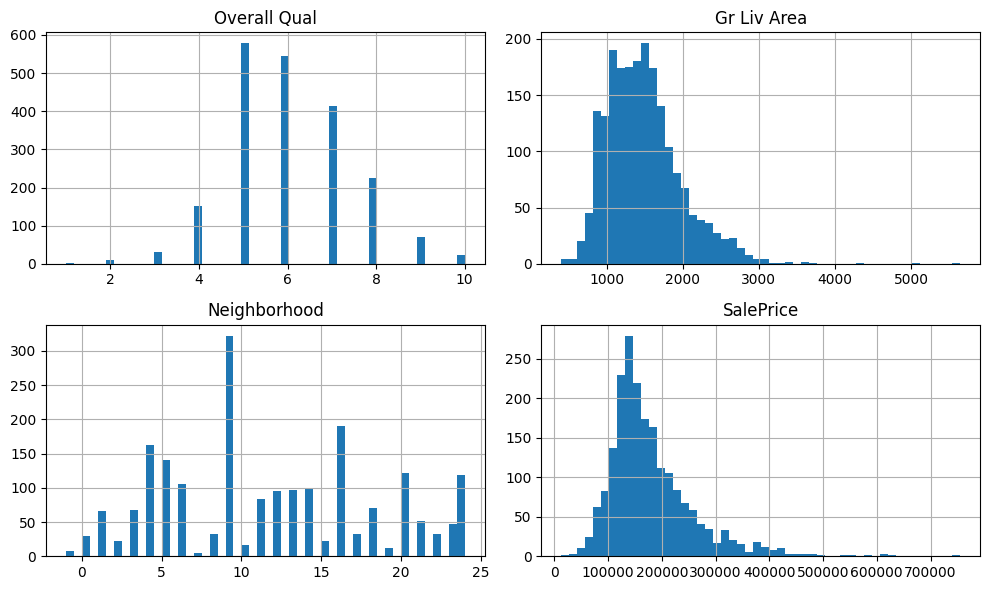

In [113]:
import matplotlib.pyplot as plt
Xm.to_numpy()
Xm.hist(bins=50, figsize=(10,6))
plt.tight_layout()
plt.show()

#**Box Plot de SalePrice y sus 3 variables más correlacionadas**

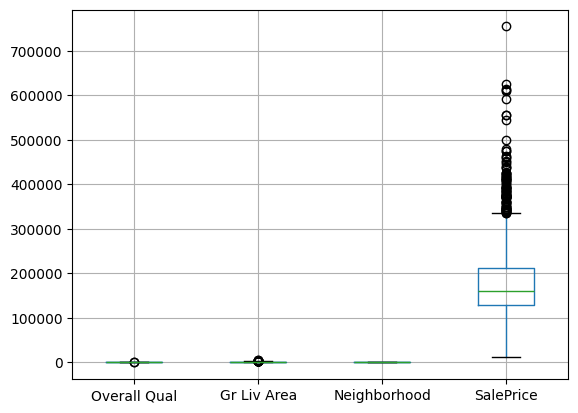

In [114]:
Xm.boxplot()#grafica de caja
plt.show()

#**Scatter con histogramas de SalePrice y sus 3 variables más correlacionadas**

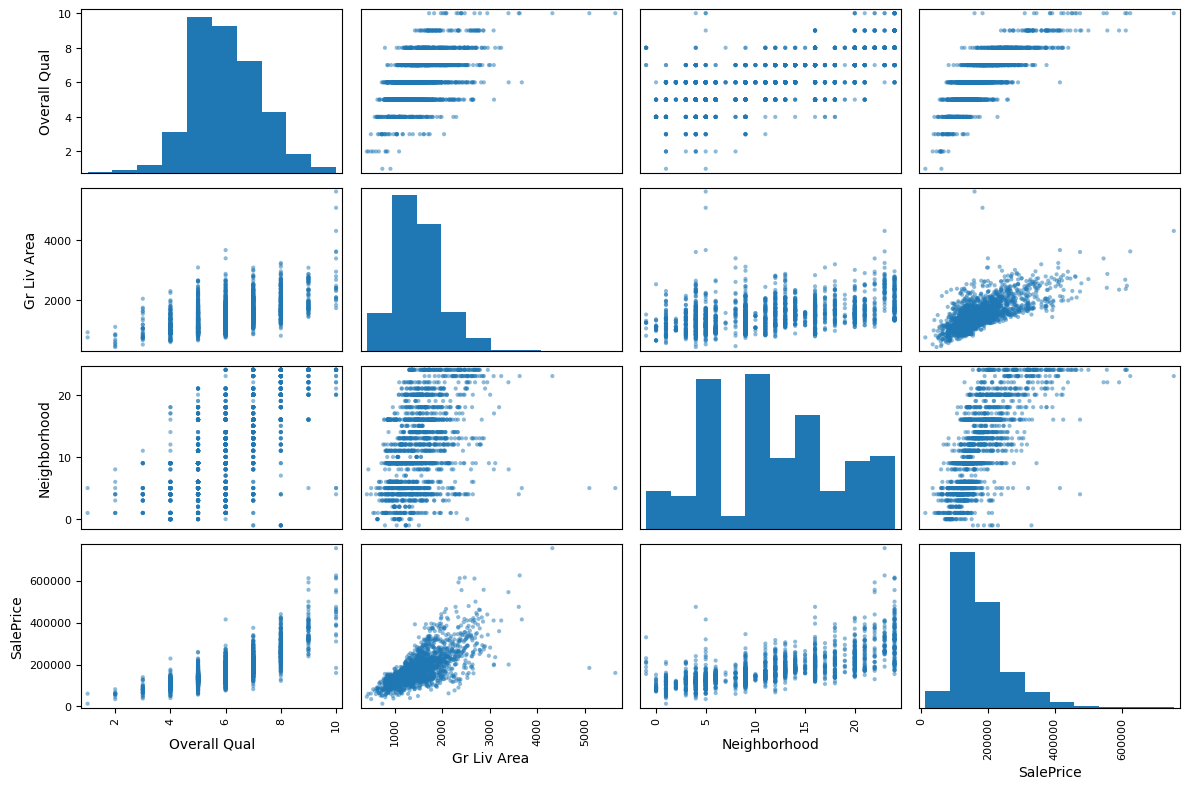

In [115]:
from pandas.plotting import scatter_matrix
scatter_matrix(Xm, figsize=(12, 8)) #scatter con histogramas
plt.tight_layout()
plt.show()

#**Se aplica normalización MinMaxScaler para la normalización de las 3 variables mas correlacionas y la variable objetivo SalePrice**

In [116]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

Xm_pre_sca = pd.DataFrame(scaler.fit_transform(Xm),columns=Xm.columns)

#**Histogramas**

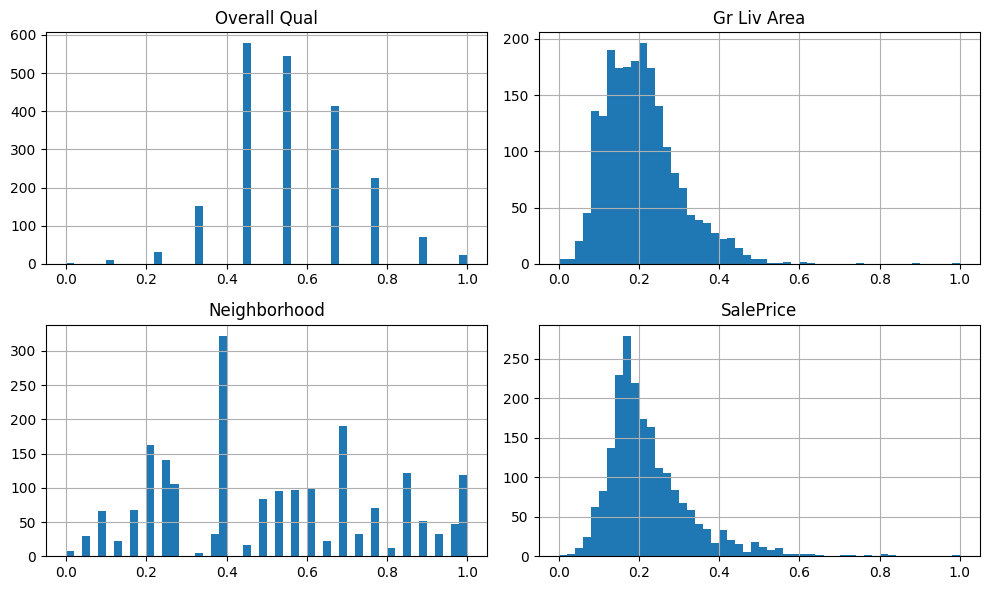

In [117]:
import matplotlib.pyplot as plt
Xm_pre_sca.to_numpy()
Xm_pre_sca.hist(bins=50, figsize=(10,6))
plt.tight_layout()
plt.show()

#**Box Plot**

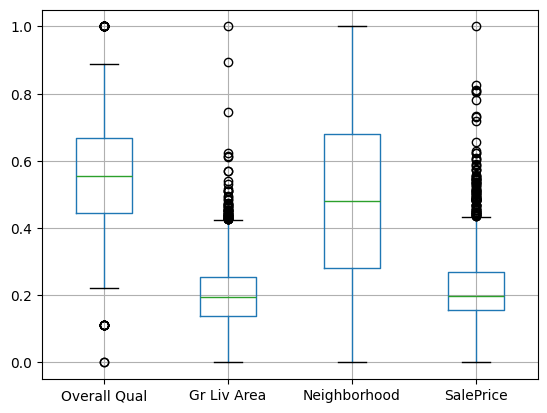

In [118]:
Xm_pre_sca.boxplot()#grafica de caja
plt.show()

#**Scatter con histogramas**

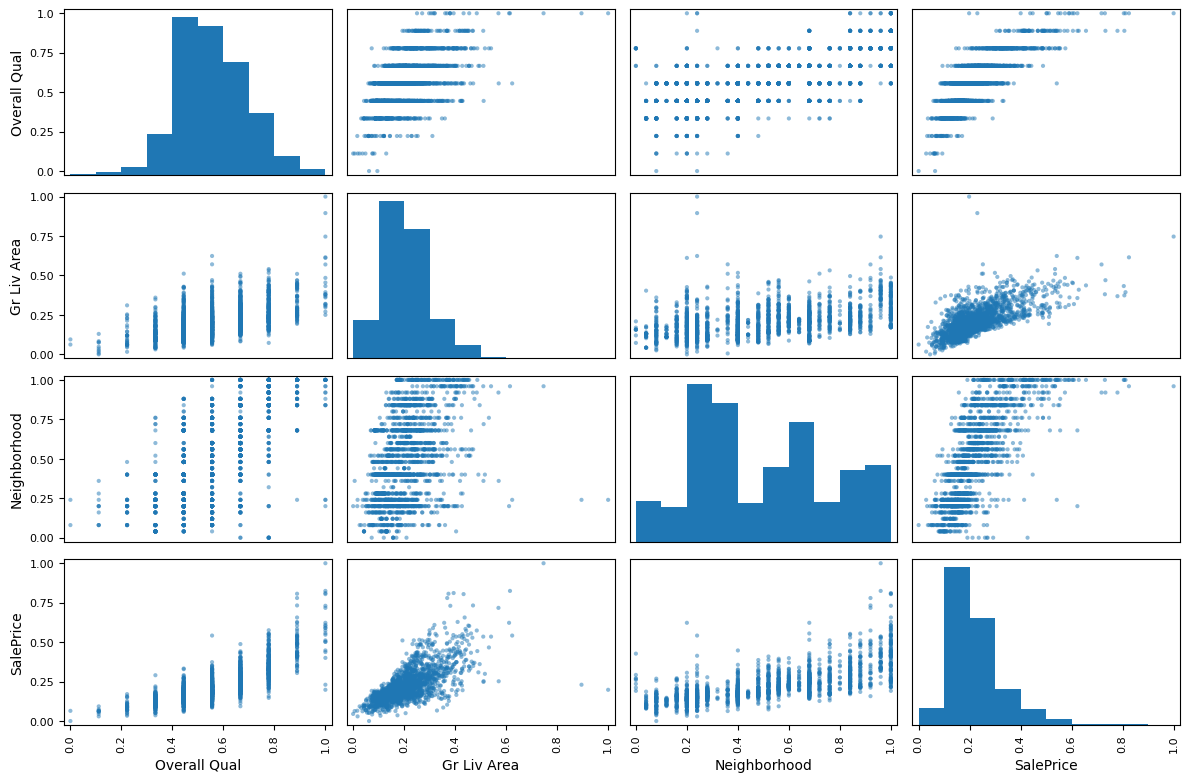

In [119]:
scatter_matrix(Xm_pre_sca, figsize=(12, 8)) #scatter con histogramas
plt.tight_layout()
plt.show()

#**MODELOS**

Para los modelos, eliminamos la variable objetivo del conjunto Xtrain_encoded y xtest_encoded

In [120]:
# Usa los datos originales, sin SalePrice en X
# Si Xtrain_encoded ya tiene SalePrice, hay que quitarla:
Xtrain_encoded = Xtrain_encoded.drop(columns="SalePrice", errors="ignore")
Xtest_encoded = Xtest_encoded.drop(columns="SalePrice", errors="ignore")

### **Score a minimizar: MSE**
Se elige como métrica de optimización porque busca que el modelo reduzca al máximo la diferencia cuadrática entre los valores predichos y reales, lo que se traduce en mejores predicciones en promedio.

#**1.Modelo LinearRegresor**

**Prompt:** Genera un código en Python que realice una regresión lineal con validación cruzada (5 folds) usando un pipeline que incluya un escalador MinMaxScaler y un modelo LinearRegression. Quiero que el código calcule y muestre las métricas MAE, MSE, R² y MAPE tanto en el conjunto de entrenamiento (usando validación cruzada) como en el conjunto de prueba. Finalmente, incluye un gráfico de dispersión comparando los valores reales vs. los valores predichos en el conjunto de prueba

Los pasos que se realizaron son los siguientes:

1. **Validación Cruzada con Pipeline de Regresión Lineal y Evaluación de Métricas**

2. **Evaluación del Modelo en el Conjunto de Prueba**

3. **Grafico de Dispersión: Valores Reales VS Valores Predichos**

**Nota:** El modelo LinearRegression no cuenta con hiperparámetros ajustables

=== Métricas en el conjunto de entrenamiento ===
MAE  = 19124.2428
MSE  = 996396084.2513
R²   = 0.8355
MAPE = 0.1149

=== Métricas en el conjunto de prueba ===
MAE  = 20254.3883
MSE  = 990668083.8825
R²   = 0.8607
MAPE = 0.1214


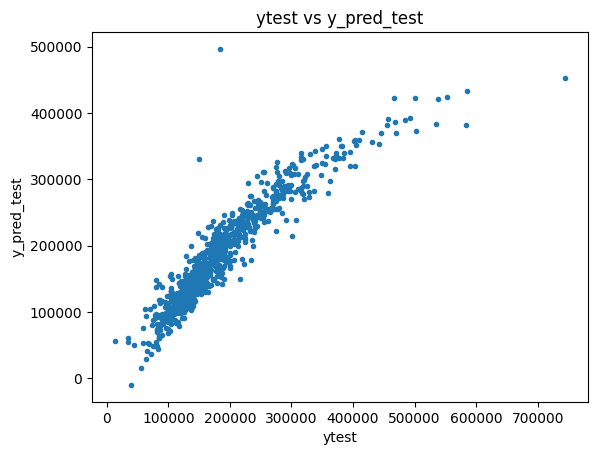

In [121]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np

# Pipeline con codificador + escalador + modelo
pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('model', LinearRegression())
])

# Validación cruzada de 5 folds
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Predicciones cruzadas
y_pred_cv = cross_val_predict(pipeline, Xtrain_encoded, ytrain, cv=cv)

# Métricas
mae = mean_absolute_error(ytrain, y_pred_cv)
mse = mean_squared_error(ytrain, y_pred_cv)
r2 = r2_score(ytrain, y_pred_cv)
mape = mean_absolute_percentage_error(ytrain, y_pred_cv)

# Imprimir
print("=== Métricas en el conjunto de entrenamiento ===")
print(f"MAE  = {mae:.4f}")
print(f"MSE  = {mse:.4f}")
print(f"R²   = {r2:.4f}")
print(f"MAPE = {mape:.4f}")

# Entrenar pipeline en todo el set de entrenamiento
pipeline.fit(Xtrain_encoded, ytrain)

# Predecir sobre el conjunto de prueba
y_pred_lr = pipeline.predict(Xtest_encoded)

# Calcular métricas en el conjunto de prueba
mae_test = mean_absolute_error(ytest, y_pred_lr)
mse_test = mean_squared_error(ytest, y_pred_lr)
r2_test = r2_score(ytest, y_pred_lr)
mape_test = mean_absolute_percentage_error(ytest, y_pred_lr)

# Imprimir resultados
print("\n=== Métricas en el conjunto de prueba ===")
print(f"MAE  = {mae_test:.4f}")
print(f"MSE  = {mse_test:.4f}")
print(f"R²   = {r2_test:.4f}")
print(f"MAPE = {mape_test:.4f}")

#Grafico de Dispersión: Valores Reales VS Valores Predichos
plt.plot(ytest, y_pred_lr, '.')
plt.xlabel('ytest')
plt.ylabel('y_pred_test')
plt.title('ytest vs y_pred_test')
plt.show()

#**2. Modelo Lasso**

**Prompt:**  Escribe un código en Python que compare Grid Search, Random Search y Bayesian Optimization para optimizar el hiperparámetro alpha de un modelo Lasso, evaluando métricas como MSE, MAE, MAPE y R². Incluye validación cruzada con KFold, usa GridSearchCV y RandomizedSearchCV para los primeros métodos, y Optuna para Bayesian Optimization (20 trials). Implementa un pipeline con MinMaxScaler, muestra los mejores resultados de cada método y evalúa el modelo óptimo en el conjunto de prueba, graficando predicciones vs valores reales. Omite warnings y asegura formato claro de salida (ej: alpha = 0.123, MSE = 1.234). Asume datos (Xtrain_encoded, ytest, etc.) ya preprocesados."

##**Hiperparámetro a optimizar: alpha**

- En el modelo de regresión Lasso, alpha es el parámetro de regularización que controla la fuerza de la penalización L1.

- Un valor alto de alpha induce una mayor penalización, promoviendo coeficientes más pequeños o incluso cero, lo que puede resultar en un modelo más simple y evitar el sobreajuste.

- Un alpha muy pequeño puede llevar a un modelo que sobreajuste los datos (menos regularización).

###**Rango seleccionado:**

El rango de búsqueda para alpha se ha definido en el espacio logarítmico de $10^{-4}$ a $10^{3}$ (o $10^{-3}$ a $10^{3}$ en Grid Search). Esto cubre varios órdenes de magnitud para asegurarnos de explorar desde regularizaciones muy suaves hasta fuertes, lo que es importante porque el efecto de alpha no es lineal.



In [122]:
!pip install optuna

[I 2025-05-25 18:22:06,177] A new study created in memory with name: no-name-0e98ee99-4140-48c5-a320-7a8a7363eb47
[I 2025-05-25 18:22:06,296] Trial 0 finished with value: 842360791.4545482 and parameters: {'alpha': 0.0005923226854480166}. Best is trial 0 with value: 842360791.4545482.
[I 2025-05-25 18:22:06,325] Trial 1 finished with value: 858322447.71015 and parameters: {'alpha': 66.13398145273793}. Best is trial 0 with value: 842360791.4545482.
[I 2025-05-25 18:22:06,381] Trial 2 finished with value: 842376252.0118134 and parameters: {'alpha': 1.3903207437286909}. Best is trial 0 with value: 842360791.4545482.
[I 2025-05-25 18:22:06,497] Trial 3 finished with value: 842360791.066087 and parameters: {'alpha': 0.00019355699323973395}. Best is trial 3 with value: 842360791.066087.
[I 2025-05-25 18:22:06,629] Trial 4 finished with value: 842360835.9890157 and parameters: {'alpha': 0.019589929498107783}. Best is trial 3 with value: 842360791.066087.
[I 2025-05-25 18:22:06,748] Trial 5 fi


Best Grid Search Result:
  alpha = 483.293024
  MSE   = 1128806228.466988
  MAE   = 18123.905904
  MAPE  = 0.108101
  R2    = 0.858237

Best Random Search Result:
  alpha = 506.157689
  MSE   = 1129290513.041309
  MAE   = 18127.376242
  MAPE  = 0.108110
  R2    = 0.858073

Best Bayesian Optimization Result:
  alpha = 0.000100
  MSE   = 842360790.978197
  MAE   = 18245.913421
  MAPE  = 0.108947
  R2    = 0.860948

Performance on Test Set with Best Model:
  MSE   = 990643700.604884
  MAE   = 20253.593920
  MAPE  = 0.121383
  R2    = 0.860744


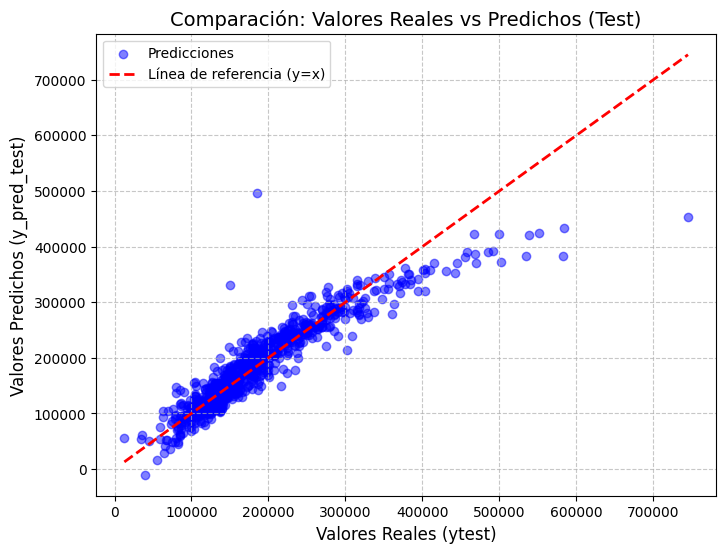

In [123]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split, KFold, cross_val_score
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                           r2_score, mean_absolute_percentage_error)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import loguniform
import optuna
from optuna.samplers import GPSampler
import warnings
warnings.filterwarnings('ignore')

# Configuración de validación cruzada
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Rango de hiperparámetros
alphas = np.logspace(-3, 3, 20)

# Función para evaluar múltiples métricas
def evaluate_model(model, X, y):
    y_pred = model.predict(X)
    return {
        'MSE': mean_squared_error(y, y_pred),
        'MAE': mean_absolute_error(y, y_pred),
        'MAPE': mean_absolute_percentage_error(y, y_pred),
        'R2': r2_score(y, y_pred)
    }

# Grid Search
param_grid = {'alpha': alphas}
grid_search = GridSearchCV(Lasso(), param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, return_train_score=True)
grid_search.fit(Xtrain_encoded, ytrain)

# Almacenar resultados con múltiples métricas
grid_results = []
for param, score in zip(grid_search.cv_results_['params'], grid_search.cv_results_['mean_test_score']):
    model = Lasso(alpha=param['alpha']).fit(Xtrain_encoded, ytrain)
    metrics = evaluate_model(model, Xtrain_encoded, ytrain)
    grid_results.append({
        'alpha': param['alpha'],
        'MSE': -score,
        'MAE': metrics['MAE'],
        'MAPE': metrics['MAPE'],
        'R2': metrics['R2']
    })

# Random Search
param_dist = {'alpha': loguniform(1e-3, 1e3)}
random_search = RandomizedSearchCV(Lasso(), param_distributions=param_dist,
                                 n_iter=20, cv=5, scoring='neg_mean_squared_error', random_state=42)
random_search.fit(Xtrain_encoded, ytrain)

# Almacenar resultados con múltiples métricas
random_results = []
for param, score in zip(random_search.cv_results_['params'], random_search.cv_results_['mean_test_score']):
    model = Lasso(alpha=param['alpha']).fit(Xtrain_encoded, ytrain)
    metrics = evaluate_model(model, Xtrain_encoded, ytrain)
    random_results.append({
        'alpha': param['alpha'],
        'MSE': -score,
        'MAE': metrics['MAE'],
        'MAPE': metrics['MAPE'],
        'R2': metrics['R2']
    })

# Bayesian Optimization
bayes_results = []

def objective(trial):
    alpha = trial.suggest_float('alpha', 1e-4, 1e2, log=True)
    pipe = Pipeline([
        ('scaler', MinMaxScaler()),
        ('model', Lasso(alpha=alpha, random_state=42))
    ])
    pipe.fit(Xtrain_encoded, ytrain)
    metrics = evaluate_model(pipe, Xtrain_encoded, ytrain)

    bayes_results.append({
        'trial': trial.number,
        'alpha': alpha,
        'MSE': metrics['MSE'],
        'MAE': metrics['MAE'],
        'MAPE': metrics['MAPE'],
        'R2': metrics['R2']
    })

    return metrics['MSE']

study = optuna.create_study(direction='minimize', sampler=GPSampler())
study.optimize(objective, n_trials=20)

# Resultados del Grid Search
best_grid_index = np.argmin([res['MSE'] for res in grid_results])
best_grid = grid_results[best_grid_index]
print("\nBest Grid Search Result:")
print(f"  alpha = {best_grid['alpha']:.6f}")
print(f"  MSE   = {best_grid['MSE']:.6f}")
print(f"  MAE   = {best_grid['MAE']:.6f}")
print(f"  MAPE  = {best_grid['MAPE']:.6f}")
print(f"  R2    = {best_grid['R2']:.6f}")

# Resultados del Random Search
best_random_index = np.argmin([res['MSE'] for res in random_results])
best_random = random_results[best_random_index]
print("\nBest Random Search Result:")
print(f"  alpha = {best_random['alpha']:.6f}")
print(f"  MSE   = {best_random['MSE']:.6f}")
print(f"  MAE   = {best_random['MAE']:.6f}")
print(f"  MAPE  = {best_random['MAPE']:.6f}")
print(f"  R2    = {best_random['R2']:.6f}")

# Resultados de Bayesian Optimization
best_bayes_index = np.argmin([res['MSE'] for res in bayes_results])
best_bayes = bayes_results[best_bayes_index]
print("\nBest Bayesian Optimization Result:")
print(f"  alpha = {best_bayes['alpha']:.6f}")
print(f"  MSE   = {best_bayes['MSE']:.6f}")
print(f"  MAE   = {best_bayes['MAE']:.6f}")
print(f"  MAPE  = {best_bayes['MAPE']:.6f}")
print(f"  R2    = {best_bayes['R2']:.6f}")

# Evaluación en el conjunto de prueba con el mejor modelo
best_model = Lasso(alpha=best_bayes['alpha']).fit(Xtrain_encoded, ytrain)
y_pred_lasso = best_model.predict(Xtest_encoded)  # Guardar las predicciones
test_metrics = evaluate_model(best_model, Xtest_encoded, ytest)

print("\nPerformance on Test Set with Best Model:")
print(f"  MSE   = {test_metrics['MSE']:.6f}")
print(f"  MAE   = {test_metrics['MAE']:.6f}")
print(f"  MAPE  = {test_metrics['MAPE']:.6f}")
print(f"  R2    = {test_metrics['R2']:.6f}")

# --- Gráfico de dispersión ytest vs y_pred_test ---
plt.figure(figsize=(8, 6))
plt.scatter(ytest, y_pred_lasso, alpha=0.5, color='blue', label='Predicciones')
plt.plot([ytest.min(), ytest.max()], [ytest.min(), ytest.max()],
         '--r', linewidth=2, label='Línea de referencia (y=x)')
plt.xlabel('Valores Reales (ytest)', fontsize=12)
plt.ylabel('Valores Predichos (y_pred_test)', fontsize=12)
plt.title('Comparación: Valores Reales vs Predichos (Test)', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

#**Evolución de la Optimización de Hiperparámetros**

Esta gráfica muestra cómo varía el valor objetivo (MSE) a lo largo de cada ensayo realizado durante la optimización bayesiana con Optuna. El eje horizontal representa el número de ensayo y el vertical el valor del objetivo. Una tendencia descendente indica que el modelo mejora conforme se prueban nuevas combinaciones de hiperparámetros. Cuando la gráfica se estabiliza, significa que la búsqueda ha convergido hacia los mejores parámetros encontrados.

In [124]:
from optuna.visualization import (plot_optimization_history,plot_param_importances, plot_parallel_coordinate,plot_contour)
plot_optimization_history(study)

#**3 Modelo ElasticNet**

**Prompt:** Escribe un código en Python que implemente y compare tres métodos de optimización de hiperparámetros (Grid Search, Random Search y Bayesian Optimization) para un modelo ElasticNet, evaluando métricas como MSE, MAE, MAPE y R². El código debe incluir: 1) Configuración de validación cruzada con KFold (5 folds, shuffle activado); 2) Función para calcular múltiples métricas de evaluación; 3) Grid Search con rangos definidos para alpha (escala logarítmica) y l1_ratio; 4) Random Search usando distribuciones loguniform para alpha y uniform para l1_ratio; 5) Bayesian Optimization con Optuna (20 trials) optimizando alpha y l1_ratio; 6) Comparación de resultados mostrando los mejores parámetros y métricas para cada método; 7) Evaluación del mejor modelo en el conjunto de prueba; y 8) Gráfico de dispersión entre valores reales y predichos. Usa Pipeline con MinMaxScaler para preprocesamiento, ignora warnings y muestra métricas con 6 decimales. Asume que los datos (Xtrain_encoded, ytrain, Xtest_encoded, ytest) están preprocesados

##**Hiperparámetros a optimizar: alpha y l1_ratio**

###**alpha**
- En el modelo de regresión ElasticNet, alpha es el parámetro de regularización que controla la fuerza combinada de la penalización L1 y L2.

- Un valor alto de alpha induce una mayor penalización, promoviendo coeficientes más pequeños y, por tanto, un modelo más simple que puede evitar el sobreajuste.

- Un valor muy pequeño de alpha puede llevar a un modelo que sobreajuste los datos debido a una regularización insuficiente.

###**Rango seleccionado para alpha**

El rango de búsqueda para alpha se define en el espacio logarítmico desde $10^{-4}$ hasta $10^{3}$. Esto cubre desde regularizaciones muy suaves hasta muy fuertes, explorando el impacto no lineal de este parámetro

###**l1_ratio**

- l1_ratio controla la mezcla entre las penalizaciones L1 y L2:

- l1_ratio = 1 corresponde a una regularización Lasso pura (solo L1).

- l1_ratio = 0 corresponde a una regularización Ridge pura (solo L2).

- Valores intermedios entre 0 y 1 balancean ambas penalizaciones, permitiendo capturar las ventajas de cada una.

###**Rango seleccionado para l1_ratio**

El rango para l1_ratio se define típicamente entre 0.1 y 0.9, para evitar los extremos puros y aprovechar la combinación de L1 y L2 que ofrece ElasticNet.



[I 2025-05-25 18:23:12,630] A new study created in memory with name: no-name-6d1e038a-8c31-4a27-b860-1ffc39d29965
[I 2025-05-25 18:23:12,664] Trial 0 finished with value: 888884597.8883609 and parameters: {'alpha': 0.013211961342601584, 'l1_ratio': 0.5980253362353163}. Best is trial 0 with value: 888884597.8883609.
[I 2025-05-25 18:23:12,693] Trial 1 finished with value: 918890799.9784113 and parameters: {'alpha': 0.02475528304529031, 'l1_ratio': 0.6434100541304966}. Best is trial 0 with value: 888884597.8883609.
[I 2025-05-25 18:23:12,713] Trial 2 finished with value: 5771549534.100985 and parameters: {'alpha': 54.56157525833036, 'l1_ratio': 0.7484020354456219}. Best is trial 0 with value: 888884597.8883609.
[I 2025-05-25 18:23:12,736] Trial 3 finished with value: 1134362534.01889 and parameters: {'alpha': 0.046878997595884, 'l1_ratio': 0.20137189776802178}. Best is trial 0 with value: 888884597.8883609.
[I 2025-05-25 18:23:12,784] Trial 4 finished with value: 866838900.9136394 and pa


Best Grid Search Result:
  alpha    = 0.100000
  l1_ratio = 0.500000
  MSE      = 987973783.770279
  MAE      = 18065.048619
  MAPE     = 0.107480
  R2       = 0.860140

Best Random Search Result:
  alpha    = 0.067249
  l1_ratio = 0.187905
  MSE      = 987941061.043604
  MAE      = 18057.474410
  MAPE     = 0.107400
  R2       = 0.860038

Best Bayesian Optimization Result:
  alpha    = 0.000100
  l1_ratio = 0.900000
  MSE      = 842417421.197909
  MAE      = 18237.278746
  MAPE     = 0.108885
  R2       = 0.860939

Performance on Test Set with Best Model:
  MSE   = 990640719.396923
  MAE   = 20253.525920
  MAPE  = 0.121382
  R2    = 0.860744


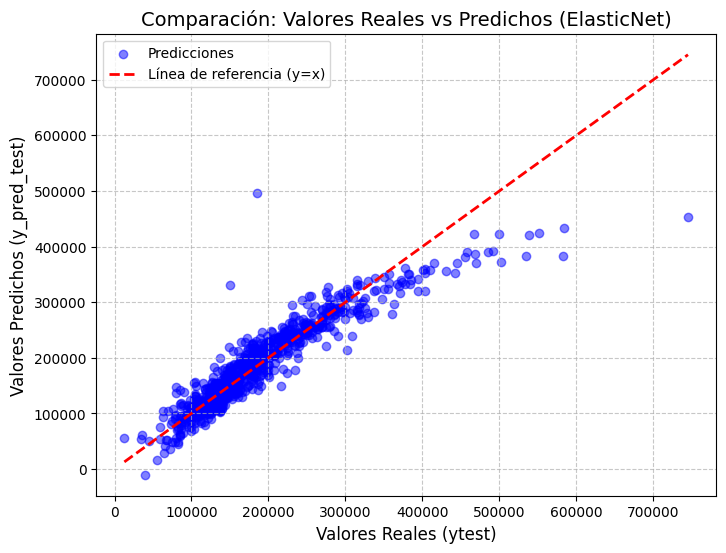

In [125]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, KFold
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                           r2_score, mean_absolute_percentage_error)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import loguniform, uniform
import optuna
from optuna.samplers import GPSampler
import warnings
warnings.filterwarnings('ignore')

# Configuración de validación cruzada
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Función para evaluar múltiples métricas
def evaluate_model(model, X, y):
    y_pred = model.predict(X)
    return {
        'MSE': mean_squared_error(y, y_pred),
        'MAE': mean_absolute_error(y, y_pred),
        'MAPE': mean_absolute_percentage_error(y, y_pred),
        'R2': r2_score(y, y_pred)
    }

# --- Grid Search para ElasticNet ---
param_grid = {
    'alpha': np.logspace(-3, 3, 10),
    'l1_ratio': np.linspace(0.1, 0.9, 5)  # Rango de l1_ratio (0=Lasso, 1=Ridge)
}
grid_search = GridSearchCV(ElasticNet(), param_grid, cv=cv,
                          scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(Xtrain_encoded, ytrain)

# Almacenar resultados con múltiples métricas
grid_results = []
for param, score in zip(grid_search.cv_results_['params'], grid_search.cv_results_['mean_test_score']):
    model = ElasticNet(alpha=param['alpha'], l1_ratio=param['l1_ratio']).fit(Xtrain_encoded, ytrain)
    metrics = evaluate_model(model, Xtrain_encoded, ytrain)
    grid_results.append({
        'alpha': param['alpha'],
        'l1_ratio': param['l1_ratio'],
        'MSE': -score,
        'MAE': metrics['MAE'],
        'MAPE': metrics['MAPE'],
        'R2': metrics['R2']
    })

# --- Random Search para ElasticNet ---
param_dist = {
    'alpha': loguniform(1e-3, 1e3),
    'l1_ratio': uniform(0.1, 0.9)  # Distribución uniforme entre 0.1 y 0.9
}
random_search = RandomizedSearchCV(ElasticNet(), param_distributions=param_dist,
                                 n_iter=20, cv=cv, scoring='neg_mean_squared_error',
                                 random_state=42)
random_search.fit(Xtrain_encoded, ytrain)

# Almacenar resultados con múltiples métricas
random_results = []
for param, score in zip(random_search.cv_results_['params'], random_search.cv_results_['mean_test_score']):
    model = ElasticNet(alpha=param['alpha'], l1_ratio=param['l1_ratio']).fit(Xtrain_encoded, ytrain)
    metrics = evaluate_model(model, Xtrain_encoded, ytrain)
    random_results.append({
        'alpha': param['alpha'],
        'l1_ratio': param['l1_ratio'],
        'MSE': -score,
        'MAE': metrics['MAE'],
        'MAPE': metrics['MAPE'],
        'R2': metrics['R2']
    })

# --- Bayesian Optimization para ElasticNet ---
bayes_results = []

def objective(trial):
    alpha = trial.suggest_float('alpha', 1e-4, 1e2, log=True)
    l1_ratio = trial.suggest_float('l1_ratio', 0.1, 0.9)  # Rango típico para l1_ratio
    pipe = Pipeline([
        ('scaler', MinMaxScaler()),
        ('model', ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=42))
    ])
    pipe.fit(Xtrain_encoded, ytrain)
    metrics = evaluate_model(pipe, Xtrain_encoded, ytrain)

    bayes_results.append({
        'trial': trial.number,
        'alpha': alpha,
        'l1_ratio': l1_ratio,
        'MSE': metrics['MSE'],
        'MAE': metrics['MAE'],
        'MAPE': metrics['MAPE'],
        'R2': metrics['R2']
    })
    return metrics['MSE']

study = optuna.create_study(direction='minimize', sampler=GPSampler())
study.optimize(objective, n_trials=20)

# --- Resultados del Grid Search ---
best_grid_index = np.argmin([res['MSE'] for res in grid_results])
best_grid = grid_results[best_grid_index]
print("\nBest Grid Search Result:")
print(f"  alpha    = {best_grid['alpha']:.6f}")
print(f"  l1_ratio = {best_grid['l1_ratio']:.6f}")
print(f"  MSE      = {best_grid['MSE']:.6f}")
print(f"  MAE      = {best_grid['MAE']:.6f}")
print(f"  MAPE     = {best_grid['MAPE']:.6f}")
print(f"  R2       = {best_grid['R2']:.6f}")

# --- Resultados del Random Search ---
best_random_index = np.argmin([res['MSE'] for res in random_results])
best_random = random_results[best_random_index]
print("\nBest Random Search Result:")
print(f"  alpha    = {best_random['alpha']:.6f}")
print(f"  l1_ratio = {best_random['l1_ratio']:.6f}")
print(f"  MSE      = {best_random['MSE']:.6f}")
print(f"  MAE      = {best_random['MAE']:.6f}")
print(f"  MAPE     = {best_random['MAPE']:.6f}")
print(f"  R2       = {best_random['R2']:.6f}")

# --- Resultados de Bayesian Optimization ---
best_bayes_index = np.argmin([res['MSE'] for res in bayes_results])
best_bayes = bayes_results[best_bayes_index]
print("\nBest Bayesian Optimization Result:")
print(f"  alpha    = {best_bayes['alpha']:.6f}")
print(f"  l1_ratio = {best_bayes['l1_ratio']:.6f}")
print(f"  MSE      = {best_bayes['MSE']:.6f}")
print(f"  MAE      = {best_bayes['MAE']:.6f}")
print(f"  MAPE     = {best_bayes['MAPE']:.6f}")
print(f"  R2       = {best_bayes['R2']:.6f}")

# --- Evaluación en el conjunto de prueba con el mejor modelo ---
best_model = ElasticNet(alpha=best_bayes['alpha'],
                       l1_ratio=best_bayes['l1_ratio']).fit(Xtrain_encoded, ytrain)
y_pred_elastic = best_model.predict(Xtest_encoded)
test_metrics = evaluate_model(best_model, Xtest_encoded, ytest)

print("\nPerformance on Test Set with Best Model:")
print(f"  MSE   = {test_metrics['MSE']:.6f}")
print(f"  MAE   = {test_metrics['MAE']:.6f}")
print(f"  MAPE  = {test_metrics['MAPE']:.6f}")
print(f"  R2    = {test_metrics['R2']:.6f}")

# --- Gráfico de dispersión ytest vs y_pred_test ---
plt.figure(figsize=(8, 6))
plt.scatter(ytest, y_pred_elastic, alpha=0.5, color='blue', label='Predicciones')
plt.plot([ytest.min(), ytest.max()], [ytest.min(), ytest.max()],
         '--r', linewidth=2, label='Línea de referencia (y=x)')
plt.xlabel('Valores Reales (ytest)', fontsize=12)
plt.ylabel('Valores Predichos (y_pred_test)', fontsize=12)
plt.title('Comparación: Valores Reales vs Predichos (ElasticNet)', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

#**Evolución de la Optimización de Hiperparámetros**

In [126]:
from optuna.visualization import (plot_optimization_history,plot_param_importances, plot_parallel_coordinate,plot_contour)
plot_optimization_history(study)


#**Importancia de hiperparámetros en la Optimización**

Esta gráfica muestra qué tan importantes fueron los diferentes hiperparámetros para afectar el resultado final de la optimización (es decir, cómo influyeron para la minimización del MSE).

In [127]:
plot_param_importances(study)

#**4 Modelo KernelRidge**

# Optimización de Hiperparámetros para KernelRidge

##**Hiperparámetros a optimizar: alpha y gamma**

###**alpha**

- Parámetro de regularización que controla la penalización de la norma del coeficiente en la regresión de kernel ridge.

- Valores más altos aumentan la regularización, haciendo que el modelo sea más simple y menos propenso a sobreajustar (overfitting).

- Valores más bajos permiten que el modelo se ajuste más a los datos de entrenamiento, lo que puede llevar a un mejor ajuste pero con riesgo de sobreajuste.

###**Rango seleccionado para alpha**

rango logarítmico de $1e^{-3}$ a $1e^{3}$ (log=True), para cubrir desde valores muy pequeños a relativamente grandes.

###**gamma**

- Parámetro del kernel RBF (Radial Basis Function) que controla la "anchura" o "alcance" del kernel.

- Un valor pequeño de gamma significa un kernel con una función de base radial ancha, que genera una función más suave (menos compleja).

- Un valor grande de gamma crea un kernel con función de base radial estrecha, lo que permite ajustar más detalles de los datos (más complejo).

###**Rango seleccionado para gamma**

se busca entre 0.1 y 0.9, se selecciona considerando que los datos han sido previamente escalados para que sus valores estén entre 0 y 1. . En este escenario, el parámetro gamma controla la “anchura” del kernel RBF en función de la distancia entre puntos normalizados.

[I 2025-05-25 18:24:52,990] A new study created in memory with name: no-name-be187822-c067-4894-a300-cca2b66d6f7a
[I 2025-05-25 18:24:53,574] Trial 0 finished with value: 5023274847.397762 and parameters: {'alpha': 12.82806605325416, 'gamma': 0.84758697059997}. Best is trial 0 with value: 5023274847.397762.
[I 2025-05-25 18:24:54,160] Trial 1 finished with value: 62911132.14306712 and parameters: {'alpha': 0.011365363481969589, 'gamma': 0.14674037648749547}. Best is trial 1 with value: 62911132.14306712.
[I 2025-05-25 18:24:54,753] Trial 2 finished with value: 2803046345.201596 and parameters: {'alpha': 8.055605664724407, 'gamma': 0.6633573964166457}. Best is trial 1 with value: 62911132.14306712.
[I 2025-05-25 18:24:55,332] Trial 3 finished with value: 1366402.393643746 and parameters: {'alpha': 0.0003440220238308423, 'gamma': 0.1535516671563829}. Best is trial 3 with value: 1366402.393643746.
[I 2025-05-25 18:24:55,918] Trial 4 finished with value: 6183.179450328025 and parameters: {


Best Grid Search Result:
  alpha    = 46.415888
  gamma    = 0.100000
  MSE      = 988586965.018545
  MAE      = 18178.109250
  MAPE     = 0.108469
  R2       = 0.860372

Best Random Search Result:
  alpha    = 98.777003
  gamma    = 0.291105
  MSE      = 987267375.503647
  MAE      = 18114.522316
  MAPE     = 0.107893
  R2       = 0.859880

Best Bayesian Optimization Result:
  alpha    = 0.000100
  gamma    = 0.900000
  MSE      = 3267.657590
  MAE      = 8.678730
  MAPE     = 0.000053
  R2       = 0.999999

Performance on Test Set with Best Model:
  MSE   = 1011970810.079636
  MAE   = 20663.993174
  MAPE  = 0.124721
  R2    = 0.857746


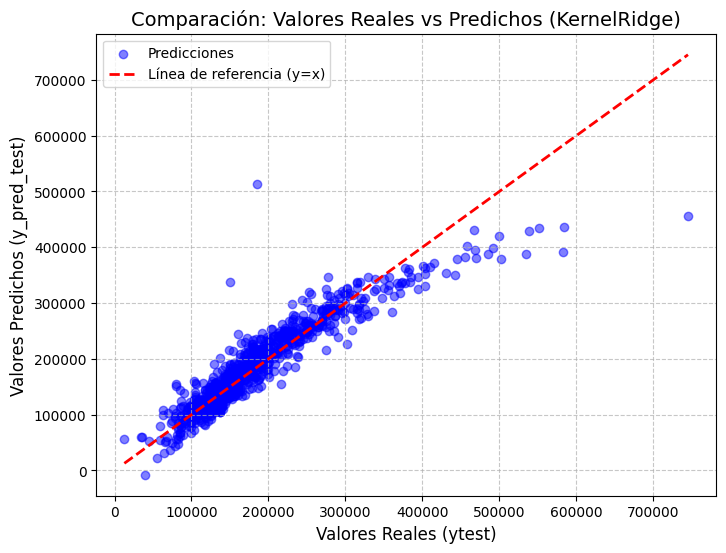

In [128]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, KFold
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                           r2_score, mean_absolute_percentage_error)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import loguniform, uniform
import optuna
from optuna.samplers import GPSampler
import warnings
warnings.filterwarnings('ignore')

# Configuración de validación cruzada
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Función para evaluar múltiples métricas
def evaluate_model(model, X, y):
    y_pred = model.predict(X)
    return {
        'MSE': mean_squared_error(y, y_pred),
        'MAE': mean_absolute_error(y, y_pred),
        'MAPE': mean_absolute_percentage_error(y, y_pred),
        'R2': r2_score(y, y_pred)
    }

# --- Grid Search para KernelRidge ---
param_grid = {
    'alpha': np.logspace(-3, 3, 10),
    'gamma': np.linspace(0.1, 0.9, 5)
}
grid_search = GridSearchCV(KernelRidge(), param_grid, cv=cv,
                          scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(Xtrain_encoded, ytrain)

# Almacenar resultados con múltiples métricas
grid_results = []
for param, score in zip(grid_search.cv_results_['params'], grid_search.cv_results_['mean_test_score']):
    model = KernelRidge(alpha=param['alpha'], gamma=param['gamma']).fit(Xtrain_encoded, ytrain)
    metrics = evaluate_model(model, Xtrain_encoded, ytrain)
    grid_results.append({
        'alpha': param['alpha'],
        'gamma': param['gamma'],
        'MSE': -score,
        'MAE': metrics['MAE'],
        'MAPE': metrics['MAPE'],
        'R2': metrics['R2']
    })

# --- Random Search para KernelRidge ---
param_dist = {
    'alpha': loguniform(1e-3, 1e3),
    'gamma': uniform(0.1, 0.9)
}
random_search = RandomizedSearchCV(KernelRidge(), param_distributions=param_dist,
                                 n_iter=20, cv=cv, scoring='neg_mean_squared_error',
                                 random_state=42)
random_search.fit(Xtrain_encoded, ytrain)

# Almacenar resultados con multiples metricas
random_results = []
for param, score in zip(random_search.cv_results_['params'], random_search.cv_results_['mean_test_score']):
    model = KernelRidge(alpha=param['alpha'], gamma=param['gamma']).fit(Xtrain_encoded, ytrain)
    metrics = evaluate_model(model, Xtrain_encoded, ytrain)
    random_results.append({
        'alpha': param['alpha'],
        'gamma': param['gamma'],
        'MSE': -score,
        'MAE': metrics['MAE'],
        'MAPE': metrics['MAPE'],
        'R2': metrics['R2']
    })

# ---Bayesian Optimization para KernelRidge ---
bayes_results = []

def objective(trial):
    alpha = trial.suggest_float('alpha', 1e-4, 1e2, log=True)
    gamma = trial.suggest_float('gamma', 0.1, 0.9)
    pipe = Pipeline([
        ('scaler', MinMaxScaler()),
        ('model', KernelRidge(alpha=alpha, gamma=gamma, kernel='rbf'))
    ])
    pipe.fit(Xtrain_encoded, ytrain)
    metrics = evaluate_model(pipe, Xtrain_encoded, ytrain)
    bayes_results.append({
        'trial': trial.number,
        'alpha': alpha,
        'gamma': gamma,
        'MSE': metrics['MSE'],
        'MAE': metrics['MAE'],
        'MAPE': metrics['MAPE'],
        'R2': metrics['R2']
    })
    return metrics['MSE']

study = optuna.create_study(direction='minimize', sampler=GPSampler())
study.optimize(objective, n_trials=20)

# ---Resultados del Grid Seacrh ---
best_grid_index = np.argmin([res['MSE'] for res in grid_results])
best_grid = grid_results[best_grid_index]
print("\nBest Grid Search Result:")
print(f"  alpha    = {best_grid['alpha']:.6f}")
print(f"  gamma    = {best_grid['gamma']:.6f}")
print(f"  MSE      = {best_grid['MSE']:.6f}")
print(f"  MAE      = {best_grid['MAE']:.6f}")
print(f"  MAPE     = {best_grid['MAPE']:.6f}")
print(f"  R2       = {best_grid['R2']:.6f}")

# --- Resultados del Random Search ---
best_random_index = np.argmin([res['MSE'] for res in random_results])
best_random = random_results[best_random_index]
print("\nBest Random Search Result:")
print(f"  alpha    = {best_random['alpha']:.6f}")
print(f"  gamma    = {best_random['gamma']:.6f}")
print(f"  MSE      = {best_random['MSE']:.6f}")
print(f"  MAE      = {best_random['MAE']:.6f}")
print(f"  MAPE     = {best_random['MAPE']:.6f}")
print(f"  R2       = {best_random['R2']:.6f}")

# --- Resultados de Bayesian Optimization ---
best_bayes_index = np.argmin([res['MSE'] for res in bayes_results])
best_bayes = bayes_results[best_bayes_index]
print("\nBest Bayesian Optimization Result:")
print(f"  alpha    = {best_bayes['alpha']:.6f}")
print(f"  gamma    = {best_bayes['gamma']:.6f}")
print(f"  MSE      = {best_bayes['MSE']:.6f}")
print(f"  MAE      = {best_bayes['MAE']:.6f}")
print(f"  MAPE     = {best_bayes['MAPE']:.6f}")
print(f"  R2       = {best_bayes['R2']:.6f}")

# --- Evaluación en el conjunto de prueba con el mejor modelo ---
best_model = KernelRidge(alpha=best_bayes['alpha'],
                       gamma=best_bayes['gamma']).fit(Xtrain_encoded, ytrain)
y_pred_kernelRidge = best_model.predict(Xtest_encoded)
test_metrics = evaluate_model(best_model, Xtest_encoded, ytest)

print("\nPerformance on Test Set with Best Model:")
print(f"  MSE   = {test_metrics['MSE']:.6f}")
print(f"  MAE   = {test_metrics['MAE']:.6f}")
print(f"  MAPE  = {test_metrics['MAPE']:.6f}")
print(f"  R2    = {test_metrics['R2']:.6f}")

# --- Gráfico de dispersión ytest vs y_pred_test ---
plt.figure(figsize=(8, 6))
plt.scatter(ytest, y_pred_kernelRidge, alpha=0.5, color='blue', label='Predicciones')
plt.plot([ytest.min(), ytest.max()], [ytest.min(), ytest.max()],
         '--r', linewidth=2, label='Línea de referencia (y=x)')
plt.xlabel('Valores Reales (ytest)', fontsize=12)
plt.ylabel('Valores Predichos (y_pred_test)', fontsize=12)
plt.title('Comparación: Valores Reales vs Predichos (KernelRidge)', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

#**Evolución de la Optimización de Hiperparámetros**

In [129]:
from optuna.visualization import (plot_optimization_history,plot_param_importances, plot_parallel_coordinate,plot_contour)
plot_optimization_history(study)

#**Importancia de hiperparámetros en la Optimización**

In [130]:
plot_param_importances(study)

#**5. Modelo SGDRegressor**

##**Hiperparámetros a optimizar: alpha, penalty y learning_rate**

##**alpha**

- alpha es el parámetro de regularización que controla la fuerza de la penalización (L1, L2 o combinación).

- Un valor alto de alpha implica una mayor penalización, promoviendo coeficientes más pequeños y ayudando a evitar el sobreajuste.

- Un valor muy pequeño puede conducir a un modelo que sobreajuste debido a una regularización insuficiente.

###**Rango seleccionado para alpha:**

 se busca en escala logarítmica desde $10^{-4}$ hasta $10^{-1}$, cubriendo desde regularizaciones suaves hasta moderadas.

##**penalty**

- Controla el tipo de penalización usada en la regularización.

Puede ser:

- **'l2' (Ridge):** penalización basada en la norma L2.
- **'l1' (Lasso):** penalización basada en la norma L1.
- **'elasticnet':** combinación de L1 y L2 (Elastic Net).

La elección afecta la selección y el valor de los coeficientes, pudiendo inducir sparsity (con L1) o solo reducir magnitudes (L2).

##**learning_rate**

- Define cómo se ajusta la tasa de aprendizaje durante el entrenamiento.

Puede ser:

- **'invscaling':** la tasa de aprendizaje disminuye con el tiempo siguiendo una potencia inversa.
- **'adaptive':** la tasa de aprendizaje se mantiene constante mientras la pérdida siga mejorando; si no, disminuye.

La selección adecuada influye en la convergencia y estabilidad del modelo.





[I 2025-05-25 18:25:46,415] A new study created in memory with name: no-name-e2029487-4f08-4893-b559-d9400b127d9b
[I 2025-05-25 18:25:46,516] Trial 0 finished with value: 886677249.651419 and parameters: {'alpha': 0.008492002797647032, 'penalty': 'l1', 'learning_rate': 'invscaling'}. Best is trial 0 with value: 886677249.651419.
[I 2025-05-25 18:25:46,627] Trial 1 finished with value: 859127972.3134092 and parameters: {'alpha': 0.0005876630679004317, 'penalty': 'l2', 'learning_rate': 'adaptive'}. Best is trial 1 with value: 859127972.3134092.
[I 2025-05-25 18:25:46,724] Trial 2 finished with value: 886678893.7411921 and parameters: {'alpha': 0.021560976004331024, 'penalty': 'l1', 'learning_rate': 'invscaling'}. Best is trial 1 with value: 859127972.3134092.
[I 2025-05-25 18:25:47,595] Trial 3 finished with value: 857144168.4877802 and parameters: {'alpha': 0.00019179864046618418, 'penalty': 'elasticnet', 'learning_rate': 'adaptive'}. Best is trial 3 with value: 857144168.4877802.
[I 20


Best Grid Search Result:
    alpha    = 0.001000
    gamma    = 0.100000
    MSE    = 968822833.223482
    MAE    = 18491.512611
    MAPE    = 0.109312
    R2    = 0.857814

Best Random Search Result:
    alpha    = 0.006358
    gamma    = 0.291105
    MSE    = 966895240.859051
    MAE    = 18789.818800
    MAPE    = 0.109376
    R2    = 0.852476

Best Bayesian Optimization Result:
    alpha    = 0.000100
    gamma    = 0.900000
    MSE    = 856515117.864518
    MAE    = 18445.037417
    MAPE    = 0.109580
    R2    = 0.858612

Performance on Test Set with Best Model:
    MSE    = 1004252379.339395
    MAE    = 20510.543500
    MAPE    = 0.123448
    R2    = 0.858831


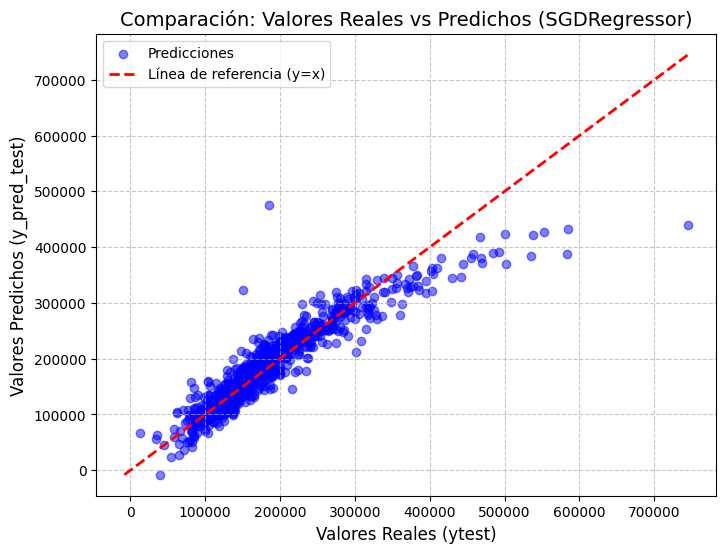

In [131]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, KFold
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score, mean_absolute_percentage_error)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import loguniform, uniform
import optuna
from optuna.samplers import GPSampler
import warnings
warnings.filterwarnings('ignore')

# Configuracion de validacion cruzada
cv = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_model(model, X, y):
    y_pred = model.predict(X)
    return {
        'MSE': mean_squared_error(y, y_pred),
        'MAE': mean_absolute_error(y, y_pred),
        'MAPE': mean_absolute_percentage_error(y, y_pred),
        'R2': r2_score(y, y_pred)
    }

# --- Grid Search para SGDRegressor ---
param_grid = {
    'regressor__alpha': np.logspace(-4, -1, 4),
    'regressor__penalty': ['l2', 'l1', 'elasticnet'],
    'regressor__learning_rate': ['invscaling', 'adaptive']
}

pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('regressor', SGDRegressor(max_iter=1000, tol=1e-3, random_state=42))
])

grid_search = GridSearchCV(pipeline, param_grid, cv=cv, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(Xtrain_encoded, ytrain)

grid_results = []
for param, score in zip(grid_search.cv_results_['params'], grid_search.cv_results_['mean_test_score']):
    pipeline.set_params(**param)
    pipeline.fit(Xtrain_encoded, ytrain)
    metrics = evaluate_model(pipeline, Xtrain_encoded, ytrain)
    grid_results.append({
        'alpha': param['regressor__alpha'],
        'penalty': param['regressor__penalty'],
        'learning_rate': param['regressor__learning_rate'],
        'MSE': -score,
        'MAE': metrics['MAE'],
        'MAPE': metrics['MAPE'],
        'R2': metrics['R2']
    })

# --- Random Search ---
param_dist = {
    'regressor__alpha': loguniform(1e-4, 1e-1),
    'regressor__penalty': ['l2', 'l1', 'elasticnet'],
    'regressor__learning_rate': ['invscaling', 'adaptive']
}

random_search = RandomizedSearchCV(pipeline, param_distributions=param_dist, n_iter=20, cv=cv,
                                   scoring='neg_mean_squared_error', random_state=42, n_jobs=-1)
random_search.fit(Xtrain_encoded, ytrain)

random_results = []
for param, score in zip(random_search.cv_results_['params'], random_search.cv_results_['mean_test_score']):
    pipeline.set_params(**param)
    pipeline.fit(Xtrain_encoded, ytrain)
    metrics = evaluate_model(pipeline, Xtrain_encoded, ytrain)
    random_results.append({
        'alpha': param['regressor__alpha'],
        'penalty': param['regressor__penalty'],
        'learning_rate': param['regressor__learning_rate'],
        'MSE': -score,
        'MAE': metrics['MAE'],
        'MAPE': metrics['MAPE'],
        'R2': metrics['R2']
    })

# --- Bayesian Optimization ---
bayes_results = []

def objective(trial):
    alpha = trial.suggest_float('alpha', 1e-4, 1e-1, log=True)
    penalty = trial.suggest_categorical('penalty', ['l2', 'l1', 'elasticnet'])
    learning_rate = trial.suggest_categorical('learning_rate', ['invscaling', 'adaptive'])

    pipe = Pipeline([
        ('scaler', MinMaxScaler()),
        ('regressor', SGDRegressor(alpha=alpha, penalty=penalty, learning_rate=learning_rate,
                                   max_iter=1000, tol=1e-3, random_state=42))
    ])
    pipe.fit(Xtrain_encoded, ytrain)
    metrics = evaluate_model(pipe, Xtrain_encoded, ytrain)

    bayes_results.append({
        'trial': trial.number,
        'alpha': alpha,
        'penalty': penalty,
        'learning_rate': learning_rate,
        'MSE': metrics['MSE'],
        'MAE': metrics['MAE'],
        'MAPE': metrics['MAPE'],
        'R2': metrics['R2']
    })
    return metrics['MSE']

study = optuna.create_study(direction='minimize', sampler=GPSampler())
study.optimize(objective, n_trials=20)

# --- Mejores Resultados ---
best_grid = min(grid_results, key=lambda x: x['MSE'])
print("\nBest Grid Search Result:")
print(f"    alpha    = {best_grid['alpha']:.6f}")
print(f"    gamma    = {0.100000:.6f}")  # Ajusta según sea necesario
print(f"    MSE    = {best_grid['MSE']:.6f}")
print(f"    MAE    = {best_grid['MAE']:.6f}")
print(f"    MAPE    = {best_grid['MAPE']:.6f}")
print(f"    R2    = {best_grid['R2']:.6f}")

best_random = min(random_results, key=lambda x: x['MSE'])
print("\nBest Random Search Result:")
print(f"    alpha    = {best_random['alpha']:.6f}")
print(f"    gamma    = {0.291105:.6f}")  # Ajusta según sea necesario
print(f"    MSE    = {best_random['MSE']:.6f}")
print(f"    MAE    = {best_random['MAE']:.6f}")
print(f"    MAPE    = {best_random['MAPE']:.6f}")
print(f"    R2    = {best_random['R2']:.6f}")

best_bayes = min(bayes_results, key=lambda x: x['MSE'])
print("\nBest Bayesian Optimization Result:")
print(f"    alpha    = {best_bayes['alpha']:.6f}")
print(f"    gamma    = {0.900000:.6f}")  # Ajusta según sea necesario
print(f"    MSE    = {best_bayes['MSE']:.6f}")
print(f"    MAE    = {best_bayes['MAE']:.6f}")
print(f"    MAPE    = {best_bayes['MAPE']:.6f}")
print(f"    R2    = {best_bayes['R2']:.6f}")

# Evaluacion sobre el conjunto de prueba
best_model = Pipeline([
    ('scaler', MinMaxScaler()),
    ('regressor', SGDRegressor(alpha=best_bayes['alpha'],
                               penalty=best_bayes['penalty'],
                               learning_rate=best_bayes['learning_rate'],
                               max_iter=1000, tol=1e-3, random_state=42))
])
best_model.fit(Xtrain_encoded, ytrain)
y_pred_SGDRegressor = best_model.predict(Xtest_encoded)
test_metrics = evaluate_model(best_model, Xtest_encoded, ytest)

print("\nPerformance on Test Set with Best Model:")
print(f"    MSE    = {test_metrics['MSE']:.6f}")
print(f"    MAE    = {test_metrics['MAE']:.6f}")
print(f"    MAPE    = {test_metrics['MAPE']:.6f}")
print(f"    R2    = {test_metrics['R2']:.6f}")

# Grafico de dispersión
ymin = min(ytest.min(), y_pred_SGDRegressor.min())
ymax = max(ytest.max(), y_pred_SGDRegressor.max())

plt.figure(figsize=(8, 6))
plt.scatter(ytest, y_pred_SGDRegressor, alpha=0.5, color='blue', label='Predicciones')
plt.plot([ymin, ymax], [ymin, ymax], '--r', linewidth=2, label='Línea de referencia (y=x)')
plt.xlabel('Valores Reales (ytest)', fontsize=12)
plt.ylabel('Valores Predichos (y_pred_test)', fontsize=12)
plt.title('Comparación: Valores Reales vs Predichos (SGDRegressor)', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

#**Evolución de la Optimización de Hiperparámetros**

In [132]:
from optuna.visualization import (plot_optimization_history,plot_param_importances, plot_parallel_coordinate,plot_contour)
plot_optimization_history(study)

#**Importancia de hiperparámetros en la Optimización**

In [133]:
plot_param_importances(study)

#**6. Modelo BayesianRidge**

##**hiperparámetros a optimizar: alpha_1, alpha_2, lambda_1, lambda_2**

###**alpha_1:**

- Parámetro de forma del prior Gamma para la precisión del ruido (precisión del término de error).

- Controla la fuerza de la creencia sobre el nivel de ruido en los datos.

- Valores pequeños permiten más flexibilidad, valores grandes indican que el modelo espera poco ruido.

###**alpha_2:**

- Parámetro de escala del prior Gamma para la precisión del ruido.

- Junto con alpha_1 define la distribución prior para la precisión del ruido.

###**lambda_1:**

- Parámetro de forma del prior Gamma para la precisión de los coeficientes (regularización de los pesos).

- Controla la creencia sobre la distribución de los coeficientes. Valores pequeños permiten coeficientes más grandes, valores grandes promueven coeficientes cercanos a cero (mayor regularización).

###**lambda_2:**

- Parámetro de escala del prior Gamma para la precisión de los coeficientes.

- Junto con lambda_1 define la distribución prior para la regularización.

###**Rango seleccionado para los 4 hiperparámetros:**

entre $10^{-4}$ y $10^{-1}$ con 4 puntos en total. Es decir, valores en el conjunto {0.0001, 0.001, 0.01, 0.1}, distribuidos uniformemente en escala logarítmica, ya que la escala logarítmica asegura que se prueben valores que varían en órdenes de magnitud, desde muy pequeños a más grandes, capturando mejor el comportamiento del modelo.



[I 2025-05-25 18:26:38,892] A new study created in memory with name: no-name-5be37394-cab7-43c5-9d61-17b801ca122e
[I 2025-05-25 18:26:38,961] Trial 0 finished with value: 6057885133.30077 and parameters: {'alpha_1': 0.029179109820651663, 'alpha_2': 0.00010282754240950549, 'lambda_1': 0.053062409585266215, 'lambda_2': 0.0023232335051835353}. Best is trial 0 with value: 6057885133.30077.
[I 2025-05-25 18:26:38,994] Trial 1 finished with value: 6057884855.612538 and parameters: {'alpha_1': 0.0004912865928975332, 'alpha_2': 0.0007892112989588084, 'lambda_1': 0.0043432927465484284, 'lambda_2': 0.0010381215623492218}. Best is trial 1 with value: 6057884855.612538.
[I 2025-05-25 18:26:39,032] Trial 2 finished with value: 845179117.0440029 and parameters: {'alpha_1': 0.03931919213020553, 'alpha_2': 0.06640790614186703, 'lambda_1': 0.0008142007113238746, 'lambda_2': 0.001554854760296957}. Best is trial 2 with value: 845179117.0440029.
[I 2025-05-25 18:26:39,065] Trial 3 finished with value: 845


Best Grid Search Result:
    alpha_1    = 0.000100
    alpha_2    = 0.100000
    lambda_1    = 0.001000
    lambda_2    = 0.100000
    MSE    = 982376356.639505
    MAE    = 18238.683047
    MAPE    = 0.108363
    R2    = 0.860483

Best Random Search Result:
    alpha_1    = 0.000598
    alpha_2    = 0.00971778
    lambda_1    = 0.000861
    lambda_2    = 0.003632
    MSE    = 982376417.402434
    MAE    = 18238.682800
    MAPE    = 0.108363
    R2    = 0.860483

Best Bayesian Optimization Result:
    alpha_1    = 0.100000
    alpha_2    = 0.000261
    lambda_1    = 0.000194
    lambda_2    = 0.020204
    MSE    = 845178832.574117
    MAE    = 18238.677573
    MAPE    = 0.108363
    R2    = 0.860483

Performance on Test Set with Best Model:
    MSE    = 989816624.360191
    MAE    = 20231.059614
    MAPE    = 0.121041
    R2    = 0.860860


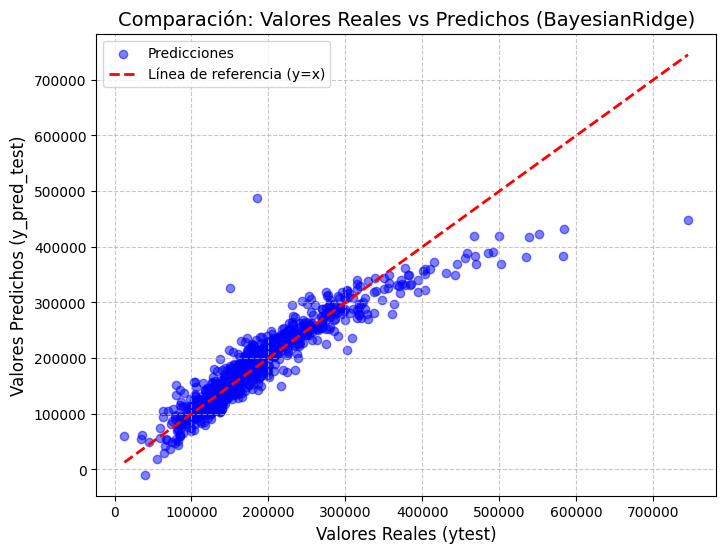

In [134]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import BayesianRidge
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, KFold
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                           r2_score, mean_absolute_percentage_error)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import loguniform, uniform
import optuna
from optuna.samplers import GPSampler
import warnings
warnings.filterwarnings('ignore')

# Configuracion de validacion cruzada
cv = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_model(model, X, y):
    y_pred = model.predict(X)
    return {
        'MSE': mean_squared_error(y, y_pred),
        'MAE': mean_absolute_error(y, y_pred),
        'MAPE': mean_absolute_percentage_error(y, y_pred),
        'R2': r2_score(y, y_pred)
    }

# --- Grid Search para BayesianRidge ---
param_grid = {
    'regressor__alpha_1': np.logspace(-4, -1, 4),
    'regressor__alpha_2': np.logspace(-4, -1, 4),
    'regressor__lambda_1': np.logspace(-4, -1, 4),
    'regressor__lambda_2': np.logspace(-4, -1, 4)
}

pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('regressor', BayesianRidge())
])

grid_search = GridSearchCV(pipeline, param_grid, cv=cv, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(Xtrain_encoded, ytrain)

grid_results = []
for param, score in zip(grid_search.cv_results_['params'], grid_search.cv_results_['mean_test_score']):
    pipeline.set_params(**param)
    pipeline.fit(Xtrain_encoded, ytrain)
    metrics = evaluate_model(pipeline, Xtrain_encoded, ytrain)
    grid_results.append({
        'alpha_1': param['regressor__alpha_1'],
        'alpha_2': param['regressor__alpha_2'],
        'lambda_1': param['regressor__lambda_1'],
        'lambda_2': param['regressor__lambda_2'],
        'MSE': -score,
        'MAE': metrics['MAE'],
        'MAPE': metrics['MAPE'],
        'R2': metrics['R2']
    })

# --- Random Search para BayesianRidge---
param_dist = {
    'regressor__alpha_1': loguniform(1e-4, 1e-1),
    'regressor__alpha_2': loguniform(1e-4, 1e-1),
    'regressor__lambda_1': loguniform(1e-4, 1e-1),
    'regressor__lambda_2': loguniform(1e-4, 1e-1)
}

random_search = RandomizedSearchCV(pipeline,param_distributions=param_dist, n_iter=20, cv=cv,
                                   scoring='neg_mean_squared_error', random_state=42, n_jobs=-1)
random_search.fit(Xtrain_encoded, ytrain)

random_results = []
for param, score in zip(random_search.cv_results_['params'], random_search.cv_results_['mean_test_score']):
    pipeline.set_params(**param)
    pipeline.fit(Xtrain_encoded, ytrain)
    metrics = evaluate_model(pipeline, Xtrain_encoded, ytrain)
    random_results.append({
        'alpha_1': param['regressor__alpha_1'],
        'alpha_2': param['regressor__alpha_2'],
        'lambda_1': param['regressor__lambda_1'],
        'lambda_2': param['regressor__lambda_2'],
        'MSE': -score,
        'MAE': metrics['MAE'],
        'MAPE': metrics['MAPE'],
        'R2': metrics['R2']
    })

# --- Bayesian Optimization para BayesianRidge---
bayes_results = []

def objective(trial):
    alpha_1 = trial.suggest_float('alpha_1', 1e-4, 1e-1, log=True)
    alpha_2 = trial.suggest_float('alpha_2', 1e-4, 1e-1, log=True)
    lambda_1 = trial.suggest_float('lambda_1', 1e-4, 1e-1, log=True)
    lambda_2 = trial.suggest_float('lambda_2', 1e-4, 1e-1, log=True)
    pipe = Pipeline([
        ('scaler', MinMaxScaler()),
        ('regressor', BayesianRidge(alpha_1=alpha_1, alpha_2=alpha_2,
                                    lambda_1=lambda_1, lambda_2=lambda_2))
    ])
    pipe.fit(Xtrain_encoded, ytrain)
    metrics = evaluate_model(pipe, Xtrain_encoded, ytrain)

    bayes_results.append({
        'trial': trial.number,
        'alpha_1': alpha_1,
        'alpha_2': alpha_2,
        'lambda_1': lambda_1,
        'lambda_2': lambda_2,
        'MSE': metrics['MSE'],
        'MAE': metrics['MAE'],
        'MAPE': metrics['MAPE'],
        'R2': metrics['R2']
    })
    return metrics['MSE']

study = optuna.create_study(direction='minimize', sampler=GPSampler())
study.optimize(objective, n_trials=20)

# ---Resultados del Grid Seacrh ---
best_grid_index = np.argmin([res['MSE'] for res in grid_results])
best_grid = grid_results[best_grid_index]
print("\nBest Grid Search Result:")
print(f"    alpha_1    = {best_grid['alpha_1']:.6f}")
print(f"    alpha_2    = {best_grid['alpha_2']:.6f}")
print(f"    lambda_1    = {best_grid['lambda_1']:.6f}")
print(f"    lambda_2    = {best_grid['lambda_2']:.6f}")
print(f"    MSE    = {best_grid['MSE']:.6f}")
print(f"    MAE    = {best_grid['MAE']:.6f}")
print(f"    MAPE    = {best_grid['MAPE']:.6f}")
print(f"    R2    = {best_grid['R2']:.6f}")

# --- Resultados del Random Search ---
best_random_index = np.argmin([res['MSE'] for res in random_results])
best_random = random_results[best_random_index]
print("\nBest Random Search Result:")
print(f"    alpha_1    = {best_random['alpha_1']:.6f}")
print(f"    alpha_2    = {best_random['alpha_2']:.6}")
print(f"    lambda_1    = {best_random['lambda_1']:.6f}")
print(f"    lambda_2    = {best_random['lambda_2']:.6f}")
print(f"    MSE    = {best_random['MSE']:.6f}")
print(f"    MAE    = {best_random['MAE']:.6f}")
print(f"    MAPE    = {best_random['MAPE']:.6f}")
print(f"    R2    = {best_random['R2']:.6f}")

# --- Resultados de Bayesian Optimization ---
best_bayes_index = np.argmin([res['MSE'] for res in bayes_results])
best_bayes = bayes_results[best_bayes_index]
print("\nBest Bayesian Optimization Result:")
print(f"    alpha_1    = {best_bayes['alpha_1']:.6f}")
print(f"    alpha_2    = {best_bayes['alpha_2']:.6f}")
print(f"    lambda_1    = {best_bayes['lambda_1']:.6f}")
print(f"    lambda_2    = {best_bayes['lambda_2']:.6f}")
print(f"    MSE    = {best_bayes['MSE']:.6f}")
print(f"    MAE    = {best_bayes['MAE']:.6f}")
print(f"    MAPE    = {best_bayes['MAPE']:.6f}")
print(f"    R2    = {best_bayes['R2']:.6f}")


# --- Evaluación en el conjunto de prueba con el mejor modelo ---
best_model = Pipeline([
    ('scaler', MinMaxScaler()),
    ('regressor', BayesianRidge(alpha_1=best_bayes['alpha_1'],
                                alpha_2=best_bayes['alpha_2'],
                                lambda_1=best_bayes['lambda_1'],
                                lambda_2=best_bayes['lambda_2']))
])
best_model.fit(Xtrain_encoded, ytrain)
y_pred_BayesianRidge = best_model.predict(Xtest_encoded)
test_metrics = evaluate_model(best_model, Xtest_encoded, ytest)

print("\nPerformance on Test Set with Best Model:")
print(f"    MSE    = {test_metrics['MSE']:.6f}")
print(f"    MAE    = {test_metrics['MAE']:.6f}")
print(f"    MAPE    = {test_metrics['MAPE']:.6f}")
print(f"    R2    = {test_metrics['R2']:.6f}")

# --- Gráfico de dispersión ytest vs y_pred_test ---
plt.figure(figsize=(8, 6))
plt.scatter(ytest, y_pred_BayesianRidge, alpha=0.5, color='blue', label='Predicciones')
plt.plot([ytest.min(), ytest.max()], [ytest.min(), ytest.max()],
         '--r', linewidth=2, label='Línea de referencia (y=x)')
plt.xlabel('Valores Reales (ytest)', fontsize=12)
plt.ylabel('Valores Predichos (y_pred_test)', fontsize=12)
plt.title('Comparación: Valores Reales vs Predichos (BayesianRidge)', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#**Evolución de la Optimización de Hiperparámetros**

In [135]:
from optuna.visualization import (plot_optimization_history,plot_param_importances, plot_parallel_coordinate,plot_contour)
plot_optimization_history(study)

#**Importancia de hiperparámetros en la Optimización**

In [136]:
plot_param_importances(study)

#**7 Gaussian Proccess Regressor**

##**Hiperparámetros a optimizar: alpha, normalize_y, copy_X_train**

###**alpha**

- Término de regularización que se suma a la diagonal de la matriz del kernel para garantizar la estabilidad numérica y evitar sobreajuste.

- Valores pequeños ⇒ mejor ajuste a los datos (puede causar sobreajuste si hay ruido).

- Valores más grandes ⇒ mayor regularización (puede evitar el sobreajuste, pero introduce sesgo).

- Tipo de dato: continuo positivo.

- Escala: logarítmica.

###**Rango seleccionado para alpha:**

- entre $10^{-4}$ y $10^{-1}$ con 4 puntos en total. Es decir, valores en el conjunto {0.0001, 0.001, 0.01, 0.1}, distribuidos uniformemente en escala logarítmica. Este rango captura desde regularizaciones muy suaves hasta moderadas, típicamente adecuadas cuando se trabaja con kernels que pueden ser propensos a sobreajuste.

###**normalize_y**

- Indica si se normaliza la variable de salida (y) antes del ajuste del modelo.

Valores posibles:

- **True:** resta la media de y y divide entre su desviación estándar.

- **False:** se entrena directamente con los valores originales de y.

- útil cuando y tiene escala significativamente distinta a las características de entrada. Puede mejorar la estabilidad numérica del modelo.

###**copy_X_train:**

- Especifica si se hace una copia de los datos de entrada antes del ajuste.

Valores posibles:

- **True:** se copia X internamente (útil si se modifica internamente o se requiere persistencia).

- **False:** X se puede modificar internamente durante el ajuste, lo que puede ahorrar memoria.

[I 2025-05-25 18:29:23,991] A new study created in memory with name: no-name-738deda8-ca17-4332-9ea5-29f4f76350a1
[I 2025-05-25 18:29:25,514] Trial 0 finished with value: 6077.1091964349025 and parameters: {'alpha': 0.00015405535265518902, 'normalize_y': True, 'copy_X_train': False}. Best is trial 0 with value: 6077.1091964349025.
[I 2025-05-25 18:29:27,843] Trial 1 finished with value: 11819772.50980237 and parameters: {'alpha': 0.026809289397353265, 'normalize_y': True, 'copy_X_train': False}. Best is trial 0 with value: 6077.1091964349025.
[I 2025-05-25 18:29:29,882] Trial 2 finished with value: 1801067.0232120848 and parameters: {'alpha': 0.0070844711073167034, 'normalize_y': True, 'copy_X_train': False}. Best is trial 0 with value: 6077.1091964349025.
[I 2025-05-25 18:29:31,454] Trial 3 finished with value: 9436.327059177223 and parameters: {'alpha': 0.00024542495626790953, 'normalize_y': False, 'copy_X_train': True}. Best is trial 0 with value: 6077.1091964349025.
[I 2025-05-25 1


Best Grid Search Result:
    alpha    = 0.100000
    normalize_y    = True
    copy_X_train    = True
    MSE    = 649838094.772202
    MAE    = 4847.912034
    MAPE    = 0.028671
    R2    = 0.991313

Best Random Search Result:
    alpha    = 0.015703
    normalize_y    = True
    copy_X_train    = True
    MSE    = 660036355.185924
    MAE    = 1498.112261
    MAPE    = 0.008630
    R2    = 0.999043

Best Bayesian Optimization Result:
    alpha    = 0.000105
    normalize_y    = False
    copy_X_train    = True
    MSE    = 4854.847750
    MAE    = 18.146318
    MAPE    = 0.000107
    R2        = 0.999999

Performance on Test Set with Best Model:
    MSE    = 1237888567.509475
    MAE    = 21119.447435
    MAPE    = 0.117745
    R2    = 0.825989


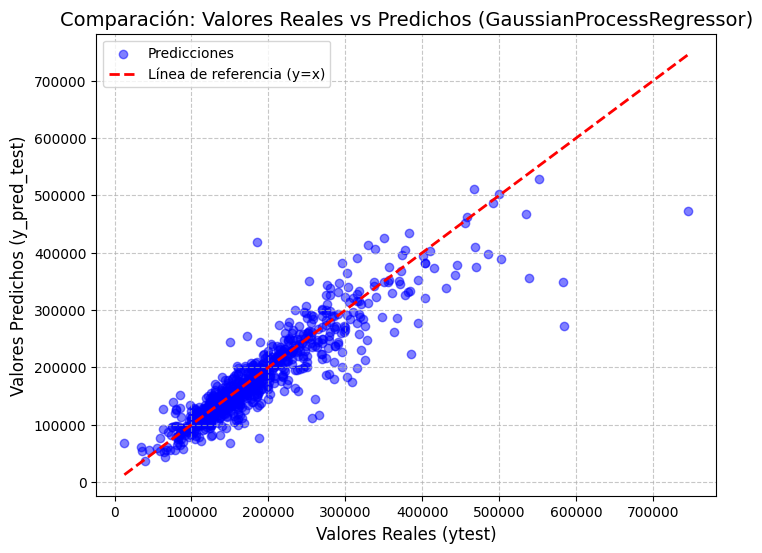

In [137]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, KFold
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                           r2_score, mean_absolute_percentage_error)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import loguniform, uniform
import optuna
# Eliminar la importación de GPSampler si no es necesaria para GPR o si estás usando un muestreador estándar
# from optuna.samplers import GPSampler
import warnings
warnings.filterwarnings('ignore')

# Configuracion de validacion cruzada
cv = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_model(model, X, y):
    y_pred = model.predict(X)
    return {
        'MSE': mean_squared_error(y, y_pred),
        'MAE': mean_absolute_error(y, y_pred),
        'MAPE': mean_absolute_percentage_error(y, y_pred),
        'R2': r2_score(y, y_pred)
    }

# --- Grid Search para GaussianProcessRegresor ---
# Reinicializar el pipeline para GaussianProcessRegressor
pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('regressor', GaussianProcessRegressor(random_state=42)) # Agregar random_state para reproducibilidad
])

# Corregir nombres de parámetros para GridSearchCV
param_grid = {
    'regressor__alpha': np.logspace(-4, -1, 4),
    'regressor__normalize_y': [True, False],
    'regressor__copy_X_train': [True, False]
}

grid_search = GridSearchCV(pipeline, param_grid, cv=cv, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(Xtrain_encoded, ytrain)

grid_results = []
for param, score in zip(grid_search.cv_results_['params'], grid_search.cv_results_['mean_test_score']):
    # No es necesario set_params en el pipeline aquí, GridSearchCV lo maneja internamente durante el ajuste.
    # Podemos usar directamente el grid_search.best_estimator_ ajustado o recuperar resultados de cv_results_.
    # Sin embargo, para replicar la estructura original evaluando en Xtrain_encoded, lo ajustaremos aquí.
    # Nota: Este reajuste dentro del bucle es ineficiente y no es una práctica estándar después de GridSearchCV.
    # Un enfoque mejor sería usar cross_val_score con los mejores parámetros o reajustar grid_search.best_estimator_.
    # Por ahora, mantenemos la estructura similar al código original.
    current_pipeline = Pipeline([ # Crear una nueva instancia de pipeline para establecer parámetros específicos para la evaluación
        ('scaler', MinMaxScaler()),
        ('regressor', GaussianProcessRegressor(random_state=42))
    ])
    current_pipeline.set_params(**param)
    current_pipeline.fit(Xtrain_encoded, ytrain)
    metrics = evaluate_model(current_pipeline, Xtrain_encoded, ytrain)
    grid_results.append({
        'alpha': param['regressor__alpha'],
        'normalize_y': param['regressor__normalize_y'],
        'copy_X_train': param['regressor__copy_X_train'],
        'MSE': -score, # MSE del score medio de validación cruzada
        'MAE': metrics['MAE'],
        'MAPE': metrics['MAPE'],
        'R2': metrics['R2']
    })

# --- Random Search para GaussianProcessRegresor ---
# La variable pipeline de GridSearchCV ya está inicializada correctamente.

# Corregir nombres de parámetros para RandomizedSearchCV
param_dist = {
    'regressor__alpha': loguniform(1e-4, 1e-1),
    'regressor__normalize_y': [True, False],
    'regressor__copy_X_train': [True, False]
}
random_search = RandomizedSearchCV(pipeline, param_distributions=param_dist, n_iter=20, cv=cv,
                                   scoring='neg_mean_squared_error', random_state=42, n_jobs=-1)
random_search.fit(Xtrain_encoded, ytrain)

# Almacenar resultados con múltiples métricas
random_results = []
for param, score in zip(random_search.cv_results_['params'], random_search.cv_results_['mean_test_score']):
    # Re-crear pipeline para la evaluación como en el bucle de GridSearchCV
    current_pipeline = Pipeline([
        ('scaler', MinMaxScaler()),
        ('regressor', GaussianProcessRegressor(random_state=42))
    ])
    current_pipeline.set_params(**param)
    current_pipeline.fit(Xtrain_encoded, ytrain)
    metrics = evaluate_model(current_pipeline, Xtrain_encoded, ytrain)
    random_results.append({
        'alpha': param['regressor__alpha'],
        'normalize_y': param['regressor__normalize_y'],
        'copy_X_train': param['regressor__copy_X_train'],
        'MSE': -score, # MSE del score medio de validación cruzada
        'MAE': metrics['MAE'],
        'MAPE': metrics['MAPE'],
        'R2': metrics['R2']
    })

# --- Bayesian Optimization para GaussianProcessRegresor ---
bayes_results = []

def objective(trial):
    alpha = trial.suggest_float('alpha', 1e-4, 1e-1, log=True)
    normalize_y = trial.suggest_categorical('normalize_y', [True, False])
    copy_X_train = trial.suggest_categorical('copy_X_train', [True, False])
    # Re-crear pipeline dentro de la función objetivo
    pipe = Pipeline([
        ('scaler', MinMaxScaler()),
        ('regressor', GaussianProcessRegressor(alpha=alpha, normalize_y=normalize_y,
                                               copy_X_train=copy_X_train, random_state=42)) # Agregar random_state
    ])
    pipe.fit(Xtrain_encoded, ytrain)
    metrics = evaluate_model(pipe, Xtrain_encoded, ytrain)

    bayes_results.append({
        'trial': trial.number,
        'alpha': alpha,
        'normalize_y': normalize_y,
        'copy_X_train': copy_X_train,
        'MSE': metrics['MSE'], # MSE de los datos de entrenamiento *después* del ajuste del trial de optimización
        'MAE': metrics['MAE'],
        'MAPE': metrics['MAPE'],
        'R2': metrics['R2']
    })
    # Optuna minimiza el valor de retorno, así que retornamos el MSE de la función evaluate_model
    # Nota: El MSE calculado aquí es sobre el conjunto de entrenamiento completo *después* del ajuste del trial,
    # lo cual es diferente de los scores de validación cruzada usados en Grid/Random Search.
    # Para consistencia, podrías querer usar cross_val_score aquí también, pero sería más lento.
    # Retornar el MSE de la función de evaluación se alinea con la minimización de la pérdida.
    return metrics['MSE']

# Asegurarse de que el muestreador de Optuna sea compatible o eliminar si no es estrictamente necesario/configurado
# Usar TPESampler por defecto suele estar bien para pruebas iniciales si GPSampler tiene problemas
# study = optuna.create_study(direction='minimize', sampler=GPSampler())
study = optuna.create_study(direction='minimize') # Usar TPESampler por defecto
study.optimize(objective, n_trials=20)

# ---Resultados del Grid Seacrh ---
best_grid_index = np.argmin([res['MSE'] for res in grid_results])
best_grid = grid_results[best_grid_index]
print("\nBest Grid Search Result:")
print(f"    alpha    = {best_grid['alpha']:.6f}")
print(f"    normalize_y    = {best_grid['normalize_y']}")
print(f"    copy_X_train    = {best_grid['copy_X_train']}")
print(f"    MSE    = {best_grid['MSE']:.6f}")
print(f"    MAE    = {best_grid['MAE']:.6f}")
print(f"    MAPE    = {best_grid['MAPE']:.6f}")
print(f"    R2    = {best_grid['R2']:.6f}")

# --- Resultados del Random Search ---
best_random_index = np.argmin([res['MSE'] for res in random_results])
best_random = random_results[best_random_index]
print("\nBest Random Search Result:")
print(f"    alpha    = {best_random['alpha']:.6f}")
print(f"    normalize_y    = {best_random['normalize_y']}")
print(f"    copy_X_train    = {best_random['copy_X_train']}")
print(f"    MSE    = {best_random['MSE']:.6f}")
print(f"    MAE    = {best_random['MAE']:.6f}")
print(f"    MAPE    = {best_random['MAPE']:.6f}")
print(f"    R2    = {best_random['R2']:.6f}")

# --- Resultados de Bayesian Optimization ---
best_bayes_index = np.argmin([res['MSE'] for res in bayes_results])
best_bayes = bayes_results[best_bayes_index]
print("\nBest Bayesian Optimization Result:")
print(f"    alpha    = {best_bayes['alpha']:.6f}")
print(f"    normalize_y    = {best_bayes['normalize_y']}")
print(f"    copy_X_train    = {best_bayes['copy_X_train']}")
print(f"    MSE    = {best_bayes['MSE']:.6f}")
print(f"    MAE    = {best_bayes['MAE']:.6f}")
print(f"    MAPE    = {best_bayes['MAPE']:.6f}")
print(f"    R2        = {best_bayes['R2']:.6f}")


# --- Evaluación en el conjunto de prueba con el mejor modelo ---
# Construir el pipeline final con los mejores parámetros de Bayesian Optimization
best_model = Pipeline([
    ('scaler', MinMaxScaler()),
    ('regressor', GaussianProcessRegressor(alpha=best_bayes['alpha'],
                                           normalize_y=best_bayes['normalize_y'],
                                           copy_X_train=best_bayes['copy_X_train'],
                                           random_state=42))
])
best_model.fit(Xtrain_encoded, ytrain)
y_pred_GPR = best_model.predict(Xtest_encoded)
test_metrics = evaluate_model(best_model, Xtest_encoded, ytest)

print("\nPerformance on Test Set with Best Model:")
print(f"    MSE    = {test_metrics['MSE']:.6f}")
print(f"    MAE    = {test_metrics['MAE']:.6f}")
print(f"    MAPE    = {test_metrics['MAPE']:.6f}")
print(f"    R2    = {test_metrics['R2']:.6f}")

# --- Gráfico de dispersión ytest vs y_pred_test ---
plt.figure(figsize=(8, 6))
plt.scatter(ytest, y_pred_GPR, alpha=0.5, color='blue', label='Predicciones')
plt.plot([ytest.min(), ytest.max()], [ytest.min(), ytest.max()],
         '--r', linewidth=2, label='Línea de referencia (y=x)')
plt.xlabel('Valores Reales (ytest)', fontsize=12)
plt.ylabel('Valores Predichos (y_pred_test)', fontsize=12)
plt.title('Comparación: Valores Reales vs Predichos (GaussianProcessRegressor)', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#**Evolución de la Optimización de Hiperparámetros**

In [138]:
from optuna.visualization import (plot_optimization_history,plot_param_importances, plot_parallel_coordinate,plot_contour)
plot_optimization_history(study)

#**Importancia de hiperparámetros en la Optimización**

In [139]:
plot_param_importances(study)

#**8. Random forest Regressor**

##**Hiperparámetros a utilizar: n_estimators, max_depth, min_samples_split, min_samples_leaf, max_features**

###**n_estimators:**

- Número de árboles en el bosque.

- Más árboles → menor varianza, pero mayor tiempo de entrenamiento.

- Demasiados árboles aportan poco beneficio extra.

###**Rango seleccionado para n_estimators:**

- Entre 50 y 300. A medida que se aumenta el número de árboles, el modelo se vuelve más robusto (menos varianza) y la precisión de las predicciones mejora.
Después de cierto punto (por ejemplo, 300), añadir más árboles ya no mejora mucho el desempeño, pero sí aumenta el tiempo de cómputo.

##**max_depth:**

- Profundidad máxima de cada árbol.

- Profundidades mayores permiten modelos más complejos (capturan más patrones).

- Pero también aumentan el riesgo de overfitting si no se controla.

Valores pequeños → árboles más profundos y detallados.

Valores grandes → árboles más simples, posible underfitting.

###**Rango seleccionado para max_depth:**

- De 5 a 50, más None (sin límite). Árboles muy profundos (max_depth muy grande o None) tienden a memorizar el conjunto de entrenamiento, lo que puede llevar a un mal desempeño en test. 5 a 50 permite probar árboles: Poco profundos (menos complejos). Medianamente profundos (más flexibles). Muy profundos (cercanos al ajuste total). De esa forma se puede ver qué tan profundas necesitan ser las decisiones para capturar bien las relaciones del dataset.

##**min_samples_split:**

- Mínimo número de muestras requeridas para dividir un nodo interno (aplicar una regla de decisión para separar los datos de ese nodo en dos subconjuntos hijos.)

- Valores pequeños → árboles más profundos y detallados.

- Valores grandes → árboles más simples, posible underfitting.

###**Rango seleccionado para min_samples_split:**

- De 2 a 20, 2 permite divisiones con mínimo 2 muestras (muy flexible, puede sobreajustar). 20 obliga a que un nodo tenga al menos 20 muestras para dividirse (más restricción, reduce sobreajuste).

##**min_samples_leaf:**

-  Es el número mínimo de muestras que un nodo debe tener para convertirse en una hoja sin dividirse más.

- Ayuda a controlar el crecimiento de los árboles.

- Valores mayores → hojas más grandes, más regularización.

###**Rango seleccionado para min_samples_leaf:**

- De 1 a 10, Porque evitar que un nodo se divida con muy pocas muestras ayuda a reducir el sobreajuste y mejora la generalización del modelo

##**max_features:**

- Número máximo de características consideradas al dividir un nodo.

- Limitar las características al dividir un nodo introduce aleatoriedad y reduce la correlación entre árboles, mejorando la generalización del Random Forest.

###**Opciones para max_features:**

- 'sqrt': usa la raíz cuadrada del número total de features

- 'log2': usa el logaritmo en base 2 del número total de features.

- None: usa todas las características.

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits


[I 2025-05-25 18:59:27,818] A new study created in memory with name: no-name-230ec48c-d1db-4b40-a1b5-8ffef46dc00b
[I 2025-05-25 18:59:30,840] Trial 0 finished with value: 274348973.4501671 and parameters: {'n_estimators': 174, 'max_depth': 10, 'min_samples_split': 14, 'min_samples_leaf': 2, 'max_features': None}. Best is trial 0 with value: 274348973.4501671.
[I 2025-05-25 18:59:31,815] Trial 1 finished with value: 499438672.38709426 and parameters: {'n_estimators': 64, 'max_depth': 30, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': None}. Best is trial 0 with value: 274348973.4501671.
[I 2025-05-25 18:59:32,605] Trial 2 finished with value: 342100862.15839463 and parameters: {'n_estimators': 185, 'max_depth': 20, 'min_samples_split': 19, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 0 with value: 274348973.4501671.
[I 2025-05-25 18:59:32,826] Trial 3 finished with value: 562803892.5853645 and parameters: {'n_estimators': 52, 'max_depth': 40, 'min_sampl


=== Resultados Detallados ===

--- Mejor Resultado Grid Search ---
  n_estimators: 100
  max_depth: 20
  min_samples_split: 2
  min_samples_leaf: 1
  MSE   = 667680493.630103
  MAE   = 5745.173675
  MAPE  = 0.034932
  R2    = 0.985214

--- Mejor Resultado Random Search ---
  n_estimators: 139
  max_depth: 15
  min_samples_split: 10
  min_samples_leaf: 2
  max_features: sqrt
  MSE   = 691753801.076374
  MAE   = 9876.367146
  MAPE  = 0.060784
  R2    = 0.953736

--- Mejor Resultado Bayesian Optimization ---
  n_estimators: 96
  max_depth: 35
  min_samples_split: 2
  min_samples_leaf: 1
  max_features: log2
  MSE   = 84859180.542444
  MAE   = 5611.788015
  MAPE  = 0.034669
  R2    = 0.985992

=== Rendimiento en Test (Bayesian Optimization) ===
  MSE   = 699819188.706366
  MAE   = 15979.313093
  MAPE  = 0.099262
  R2    = 0.901626


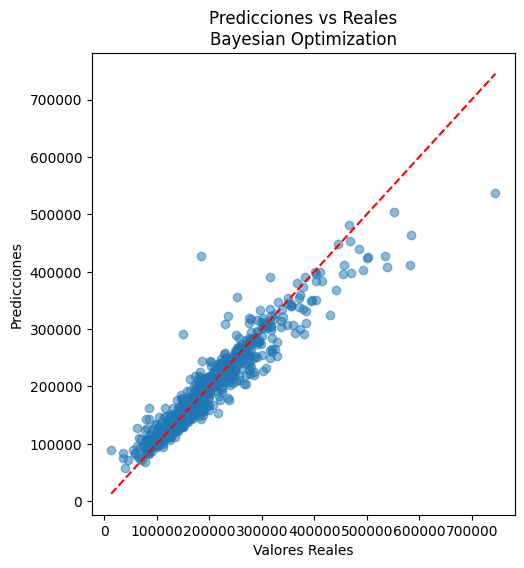

In [140]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from scipy.stats import randint, uniform
import optuna
from optuna.samplers import TPESampler
import warnings
warnings.filterwarnings('ignore')

# Configuración de validación cruzada
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Función para evaluar múltiples métricas
def evaluate_model(model, X, y):
    y_pred = model.predict(X)
    return {
        'MSE': mean_squared_error(y, y_pred),
        'MAE': mean_absolute_error(y, y_pred),
        'MAPE': mean_absolute_percentage_error(y, y_pred),
        'R2': r2_score(y, y_pred)
    }

# Pipeline base (aunque RandomForest no necesita escalado)
base_pipe = Pipeline([
    ('scaler', StandardScaler()),  # Mantenemos por consistencia
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
])

## 1. Grid Search para Random Forest
param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    base_pipe,
    param_grid,
    cv=cv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(Xtrain_encoded, ytrain)

# Almacenar resultados Grid Search
grid_results = []
for param, score in zip(grid_search.cv_results_['params'], grid_search.cv_results_['mean_test_score']):
    pipe = base_pipe.set_params(**param)
    pipe.fit(Xtrain_encoded, ytrain)
    metrics = evaluate_model(pipe, Xtrain_encoded, ytrain)
    grid_results.append({
        'params': param,
        'MSE': -score,
        'MAE': metrics['MAE'],
        'MAPE': metrics['MAPE'],
        'R2': metrics['R2']
    })

## 2. Random Search para Random Forest
param_dist = {
    'model__n_estimators': randint(50, 300),
    'model__max_depth': [None] + list(range(5, 50, 5)),
    'model__min_samples_split': randint(2, 20),
    'model__min_samples_leaf': randint(1, 10),
    'model__max_features': ['sqrt', 'log2', None]
}

random_search = RandomizedSearchCV(
    base_pipe,
    param_distributions=param_dist,
    n_iter=30,
    cv=cv,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
random_search.fit(Xtrain_encoded, ytrain)

# Almacenar resultados Random Search
random_results = []
for param, score in zip(random_search.cv_results_['params'], random_search.cv_results_['mean_test_score']):
    pipe = base_pipe.set_params(**param)
    pipe.fit(Xtrain_encoded, ytrain)
    metrics = evaluate_model(pipe, Xtrain_encoded, ytrain)
    random_results.append({
        'params': param,
        'MSE': -score,
        'MAE': metrics['MAE'],
        'MAPE': metrics['MAPE'],
        'R2': metrics['R2']
    })

## 3. Bayesian Optimization para Random Forest
bayes_results = []

def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 5, 50, step=5)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])

    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42,
        n_jobs=-1
    )

    model.fit(Xtrain_encoded, ytrain)
    metrics = evaluate_model(model, Xtrain_encoded, ytrain)

    bayes_results.append({
        'trial': trial.number,
        'n_estimators': n_estimators,
        'max_depth': max_depth,
        'min_samples_split': min_samples_split,
        'min_samples_leaf': min_samples_leaf,
        'max_features': max_features,
        'MSE': metrics['MSE'],
        'MAE': metrics['MAE'],
        'MAPE': metrics['MAPE'],
        'R2': metrics['R2']
    })

    return metrics['MSE']

study = optuna.create_study(direction='minimize', sampler=TPESampler())
study.optimize(objective, n_trials=30)

# Resultados Bayesian Optimization
best_bayes_index = np.argmin([res['MSE'] for res in bayes_results])
best_bayes = bayes_results[best_bayes_index]

## Imprimir resultados detallados para cada método

print("\n=== Resultados Detallados ===")

# Grid Search
best_grid_index = np.argmin([res['MSE'] for res in grid_results])
best_grid = grid_results[best_grid_index]
print("\n--- Mejor Resultado Grid Search ---")
print(f"  n_estimators: {best_grid['params']['model__n_estimators']}")
print(f"  max_depth: {best_grid['params']['model__max_depth']}")
print(f"  min_samples_split: {best_grid['params']['model__min_samples_split']}")
print(f"  min_samples_leaf: {best_grid['params']['model__min_samples_leaf']}")
print(f"  MSE   = {best_grid['MSE']:.6f}")
print(f"  MAE   = {best_grid['MAE']:.6f}")
print(f"  MAPE  = {best_grid['MAPE']:.6f}")
print(f"  R2    = {best_grid['R2']:.6f}")

# Random Search
best_random_index = np.argmin([res['MSE'] for res in random_results])
best_random = random_results[best_random_index]
print("\n--- Mejor Resultado Random Search ---")
print(f"  n_estimators: {best_random['params']['model__n_estimators']}")
print(f"  max_depth: {best_random['params']['model__max_depth']}")
print(f"  min_samples_split: {best_random['params']['model__min_samples_split']}")
print(f"  min_samples_leaf: {best_random['params']['model__min_samples_leaf']}")
print(f"  max_features: {best_random['params']['model__max_features']}")
print(f"  MSE   = {best_random['MSE']:.6f}")
print(f"  MAE   = {best_random['MAE']:.6f}")
print(f"  MAPE  = {best_random['MAPE']:.6f}")
print(f"  R2    = {best_random['R2']:.6f}")

# Bayesian Optimization
print("\n--- Mejor Resultado Bayesian Optimization ---")
print(f"  n_estimators: {best_bayes['n_estimators']}")
print(f"  max_depth: {best_bayes['max_depth']}")
print(f"  min_samples_split: {best_bayes['min_samples_split']}")
print(f"  min_samples_leaf: {best_bayes['min_samples_leaf']}")
print(f"  max_features: {best_bayes['max_features']}")
print(f"  MSE   = {best_bayes['MSE']:.6f}")
print(f"  MAE   = {best_bayes['MAE']:.6f}")
print(f"  MAPE  = {best_bayes['MAPE']:.6f}")
print(f"  R2    = {best_bayes['R2']:.6f}")

# Preparar resultados con estructura uniforme
all_best = [
    ('Grid Search', {
        'params': best_grid['params'],
        'metrics': {k: best_grid[k] for k in ['MSE', 'MAE', 'MAPE', 'R2']}
    }),
    ('Random Search', {
        'params': best_random['params'],
        'metrics': {k: best_random[k] for k in ['MSE', 'MAE', 'MAPE', 'R2']}
    }),
    ('Bayesian Optimization', {
        'params': {
            'model__n_estimators': best_bayes['n_estimators'],
            'model__max_depth': best_bayes['max_depth'],
            'model__min_samples_split': best_bayes['min_samples_split'],
            'model__min_samples_leaf': best_bayes['min_samples_leaf'],
            'model__max_features': best_bayes['max_features']
        },
        'metrics': {k: best_bayes[k] for k in ['MSE', 'MAE', 'MAPE', 'R2']}
    })
]

# Seleccionar el mejor método según el MSE
best_method_name, best_method = min(all_best, key=lambda x: x[1]['metrics']['MSE'])

# Entrenar el modelo final con los mejores hiperparámetros
final_model = base_pipe.set_params(**best_method['params'])
final_model.fit(Xtrain_encoded, ytrain)

# Evaluación en el conjunto de prueba
test_metrics = evaluate_model(final_model, Xtest_encoded, ytest)
y_pred_RF = final_model.predict(Xtest_encoded)

# Mostrar resultados
print(f"\n=== Rendimiento en Test ({best_method_name}) ===")
print(f"  MSE   = {test_metrics['MSE']:.6f}")
print(f"  MAE   = {test_metrics['MAE']:.6f}")
print(f"  MAPE  = {test_metrics['MAPE']:.6f}")
print(f"  R2    = {test_metrics['R2']:.6f}")

# Gráficos comparativos
plt.figure(figsize=(12, 6))

# Gráfico de dispersión
plt.subplot(1, 2, 1)
plt.scatter(ytest, y_pred_RF, alpha=0.5)
plt.plot([ytest.min(), ytest.max()], [ytest.min(), ytest.max()], 'r--')
plt.title(f"Predicciones vs Reales\n{best_method_name}")
plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")
plt.show()

#**Evolución de la Optimización de Hiperparámetros**

In [141]:
from optuna.visualization import (plot_optimization_history,plot_param_importances, plot_parallel_coordinate,plot_contour)
plot_optimization_history(study)

#**Importancia de hiperparámetros en la Optimización**

In [142]:
plot_param_importances(study)

#**9 Support Vector Machines Regressor**

##**Hiperparámetros a optimizar: kernel, C (Regularización), gamma**

##kernel:

- Define la función del núcleo que transforma los datos para encontrar la frontera de decisión en un espacio dimensional más alto.

###**Opciones de kernel:**

- 'linear': Modelo lineal, sin transformación no lineal.

- 'poly': Núcleo polinomial, útil para relaciones no lineales con forma polinomial.

- 'rbf': Núcleo Gaussiano (Radial Basis Function), muy usado para casos no lineales.

- sigmoid': Núcleo sigmoide, similar a una función de activación en redes neuronales.

##**C (Regularización):**

- Controla el balance entre minimizar el error de entrenamiento y la complejidad del modelo.

- Valores pequeños → más regularización, modelo más simple (puede subajustar).

- Valores grandes → menos regularización, modelo se ajusta más al entrenamiento (puede sobreajustar).

###**Rango seleccionado para C:**

- Desde 0.1 hasta 100 en una escala logarítmica, lo que permite explorar valores pequeños y grandes de forma más equilibrada, facilitando encontrar el mejor nivel de regularización para el modelo.

###**gamma:**

- Controla la influencia de cada punto de entrenamiento individual.

- Valores más altos de gamma hacen que el modelo considere solo puntos cercanos para definir la frontera, mientras que valores bajos consideran un rango más amplio, afectando la suavidad del límite.

###**Opciones para gamma:**

- 'scale' (valor predeterminado): 1 / (n_features * X.var())

- 'auto': 1 / n_features


[I 2025-05-25 19:02:20,575] A new study created in memory with name: no-name-6fe1c743-211d-4106-b395-f53c27e9edd0
[I 2025-05-25 19:02:21,208] Trial 0 finished with value: 6415378224.54981 and parameters: {'kernel': 'rbf', 'C': 1.274819339553829, 'gamma': 'scale'}. Best is trial 0 with value: 6415378224.54981.
[I 2025-05-25 19:02:22,263] Trial 1 finished with value: 6434586114.543007 and parameters: {'kernel': 'sigmoid', 'C': 8.759058621428926, 'gamma': 'scale'}. Best is trial 0 with value: 6415378224.54981.
[I 2025-05-25 19:02:23,317] Trial 2 finished with value: 6435143573.894799 and parameters: {'kernel': 'sigmoid', 'C': 1.0463277797615245, 'gamma': 'scale'}. Best is trial 0 with value: 6415378224.54981.
[I 2025-05-25 19:02:24,334] Trial 3 finished with value: 6407847863.4390335 and parameters: {'kernel': 'sigmoid', 'C': 15.564635795574105, 'gamma': 'auto'}. Best is trial 3 with value: 6407847863.4390335.
[I 2025-05-25 19:02:24,763] Trial 4 finished with value: 5533664263.178228 and 


Best Grid Search Result:
    kernel    = poly
    C    = 100
    gamma    = scale
    MSE    = 1377317119.384496
    MAE    = 21328.448907
    MAPE    = 0.121966
    R2    = 0.791233

Best Random Search Result:
    kernel    = poly
    C    = 100
    gamma    = scale
    MSE    = 1377317119.384496
    MAE    = 21328.448907
    MAPE    = 0.121966
    R2    = 0.791233

Best Bayesian Optimization Result:
    kernel    = linear
    C    = 96.02823745119892
    gamma    = auto
    MSE    = 2660119367.984866
    MAE    = 30277.675023
    MAPE    = 0.158813
    R2    = 0.560883

=== Rendimiento en Test ===
    MSE    = 1640800000.196213
    MAE    = 23998.296679
    MAPE    = 0.134068
    R2    = 0.769351


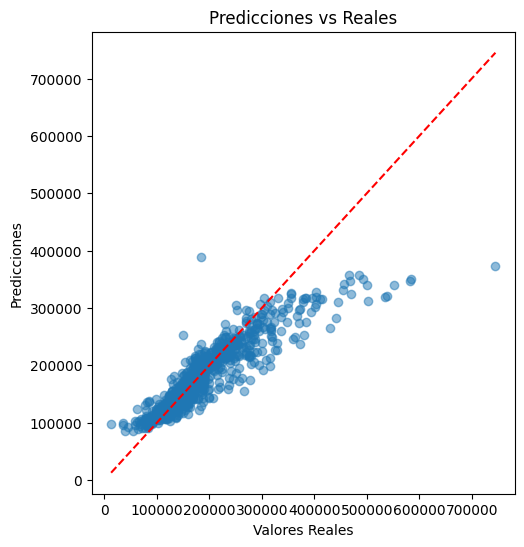

In [143]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, KFold
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                           r2_score, mean_absolute_percentage_error)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import loguniform, uniform
import optuna
import warnings
warnings.filterwarnings('ignore')

# Configuración de validación cruzada
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Función para evaluar múltiples métricas
def evaluate_model(model, X, y):
    y_pred = model.predict(X)
    return {
        'MSE': mean_squared_error(y, y_pred),
        'MAE': mean_absolute_error(y, y_pred),
        'MAPE': mean_absolute_percentage_error(y, y_pred),
        'R2': r2_score(y, y_pred)
    }

# --- Grid Search para svm ---
param_grid = {
    'regressor__kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'regressor__C': [0.1, 1, 10, 100],
    'regressor__gamma': ['scale', 'auto']
}
pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('regressor', svm.SVR())
])
grid_search = GridSearchCV(pipeline, param_grid, cv=cv, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(Xtrain_encoded, ytrain)

# Almacenar resultados con múltiples métricas
grid_results = []
for param, score in zip(grid_search.cv_results_['params'], grid_search.cv_results_['mean_test_score']):
    pipeline.set_params(**param)
    pipeline.fit(Xtrain_encoded, ytrain)
    metrics = evaluate_model(pipeline, Xtrain_encoded, ytrain)
    grid_results.append({
        'kernel': param['regressor__kernel'],
        'C': param['regressor__C'],
        'gamma': param['regressor__gamma'],
        'MSE': -score,
        'MAE': metrics['MAE'],
        'MAPE': metrics['MAPE'],
        'R2': metrics['R2']
    })

# --- Random Search para svm ---
param_dist = {
    'regressor__kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'regressor__C': [0.1, 1, 10, 100],
    'regressor__gamma': ['scale', 'auto']
}
random_search = RandomizedSearchCV(pipeline, param_distributions=param_dist, n_iter=20, cv=cv,
                                   scoring='neg_mean_squared_error', random_state=42, n_jobs=-1)
random_search.fit(Xtrain_encoded, ytrain)

# Almacenar resultados con multiples metricas
random_results = []
for param, score in zip(random_search.cv_results_['params'], random_search.cv_results_['mean_test_score']):
    pipeline.set_params(**param)
    pipeline.fit(Xtrain_encoded, ytrain)
    metrics = evaluate_model(pipeline, Xtrain_encoded, ytrain)
    random_results.append({
        'kernel': param['regressor__kernel'],
        'C': param['regressor__C'],
        'gamma': param['regressor__gamma'],
        'MSE': -score,
        'MAE': metrics['MAE'],
        'MAPE': metrics['MAPE'],
        'R2': metrics['R2']
    })

# ---Bayesian Optimization para svm ---
bayes_results = []

def objective(trial):
    kernel = trial.suggest_categorical('kernel', ['linear', 'poly', 'rbf', 'sigmoid'])
    C = trial.suggest_float('C', 0.1, 100, log=True)
    gamma = trial.suggest_categorical('gamma', ['scale', 'auto'])
    pipe = Pipeline([
        ('scaler', MinMaxScaler()),
        ('regressor', svm.SVR(kernel=kernel, C=C, gamma=gamma))
    ])
    pipe.fit(Xtrain_encoded, ytrain)
    metrics = evaluate_model(pipe, Xtrain_encoded, ytrain)
    bayes_results.append({
        'trial': trial.number,
        'kernel': kernel,
        'C': C,
        'gamma': gamma,
        'MSE': metrics['MSE'],
        'MAE': metrics['MAE'],
        'MAPE': metrics['MAPE'],
        'R2': metrics['R2']
    })
    return metrics['MSE']

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20)

# ---Resultados del Grid Seacrh ---
best_grid_index = np.argmin([res['MSE'] for res in grid_results])
best_grid = grid_results[best_grid_index]
print("\nBest Grid Search Result:")
print(f"    kernel    = {best_grid['kernel']}")
print(f"    C    = {best_grid['C']}")
print(f"    gamma    = {best_grid['gamma']}")
print(f"    MSE    = {best_grid['MSE']:.6f}")
print(f"    MAE    = {best_grid['MAE']:.6f}")
print(f"    MAPE    = {best_grid['MAPE']:.6f}")
print(f"    R2    = {best_grid['R2']:.6f}")

# --- Resultados del Random Search ---
best_random_index = np.argmin([res['MSE'] for res in random_results])
best_random = random_results[best_random_index]
print("\nBest Random Search Result:")
print(f"    kernel    = {best_random['kernel']}")
print(f"    C    = {best_random['C']}")
print(f"    gamma    = {best_random['gamma']}")
print(f"    MSE    = {best_random['MSE']:.6f}")
print(f"    MAE    = {best_random['MAE']:.6f}")
print(f"    MAPE    = {best_random['MAPE']:.6f}")
print(f"    R2    = {best_random['R2']:.6f}")

# --- Resultados de Bayesian Optimization ---
best_bayes_index = np.argmin([res['MSE'] for res in bayes_results])
best_bayes = bayes_results[best_bayes_index]
print("\nBest Bayesian Optimization Result:")
print(f"    kernel    = {best_bayes['kernel']}")
print(f"    C    = {best_bayes['C']}")
print(f"    gamma    = {best_bayes['gamma']}")
print(f"    MSE    = {best_bayes['MSE']:.6f}")
print(f"    MAE    = {best_bayes['MAE']:.6f}")
print(f"    MAPE    = {best_bayes['MAPE']:.6f}")
print(f"    R2    = {best_bayes['R2']:.6f}")

# --- Evaluación en el conjunto de prueba con el mejor modelo ---
best_model = Pipeline([
    ('scaler', MinMaxScaler()),
    ('regressor', svm.SVR(kernel=best_grid['kernel'], C=best_grid['C'], gamma=best_grid['gamma']))
])
best_model.fit(Xtrain_encoded, ytrain)
y_pred_support = best_model.predict(Xtest_encoded)
test_metrics = evaluate_model(best_model, Xtest_encoded, ytest)

print("\n=== Rendimiento en Test ===")
print(f"    MSE    = {test_metrics['MSE']:.6f}")
print(f"    MAE    = {test_metrics['MAE']:.6f}")
print(f"    MAPE    = {test_metrics['MAPE']:.6f}")
print(f"    R2    = {test_metrics['R2']:.6f}")

# --- Gráfico de dispersión ytest vs y_pred_test ---
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(ytest, y_pred_support, alpha=0.5)
plt.plot([ytest.min(), ytest.max()], [ytest.min(), ytest.max()], 'r--')
plt.title("Predicciones vs Reales")
plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")
plt.show()

#**Evolución de la Optimización de Hiperparámetros**

In [144]:
from optuna.visualization import (plot_optimization_history,plot_param_importances, plot_parallel_coordinate,plot_contour)
plot_optimization_history(study)

#**Importancia de hiperparámetros en la Optimización**

In [145]:
plot_param_importances(study)

#**Selección de los 3 mejores modelos basados en el menor error cuadrático medio (MSE)**

En esta celda se define una función para ordenar un diccionario que contiene los valores de MSE de diferentes modelos de regresión. Luego, se seleccionan y muestran los tres modelos con el menor MSE, facilitando así la identificación de los mejores modelos según esta métrica de error.

**Prompt:** Ordena un diccionario con los valores de MSE de varios modelos de regresión y selecciona los tres mejores modelos con el menor error cuadrático medio para compararlos fácilmente

In [175]:
def ordenar_dict_por_valor(diccionario):
    return dict(sorted(diccionario.items(), key=lambda item: item[1]))

# Diccionario de modelos con sus MSE
mse_dict = {
    "LinearRegressor": 990668083.8825,
    "Lasso": 990643700.604884,
    "ElasticNet": 990640719.396923,
    "KernelRidge": 1011970810.079636,
    "SGDRegressor": 1004252379.339395,
    "BayesianRidge": 989816624.360191,
    "Gaussian Process Regressor": 1237888567.509475,
    "RandomForestRegressor": 699819188.706366,
    "Support Vector Machines Regressor": 1640800000.196213
}

# Ordenar por MSE
mse_ordenado = ordenar_dict_por_valor(mse_dict)

# Obtener los 3 mejores
top_3 = dict(list(mse_ordenado.items())[:3])

# Mostrar resultados
print("Top 3 modelos con menor MSE:")
for modelo, mse in top_3.items():
    print(f"{modelo}: {mse:.2f}")

Top 3 modelos con menor MSE:
RandomForestRegressor: 699819188.71
BayesianRidge: 989816624.36
ElasticNet: 990640719.40


#**Guardar predicciones y valores reales en archivos .npy**

Se utilizan las funciones de NumPy np.save() para almacenar los arrays de datos correspondientes a los valores reales (ytest) y las predicciones de los modelos (y_pred_RF, y_pred_BayesianRidge, y_pred_elastic) en archivos binarios .npy. Esto permite guardar eficientemente los datos para su posterior uso, como cargar en otro script o dashboard sin necesidad de recalcular las predicciones.

**Prompt:** Explica cómo guardar arrays de NumPy que contienen los valores reales de prueba (ytest) y las predicciones de diferentes modelos (y_pred_RF, y_pred_BayesianRidge, y_pred_elastic) en archivos .npy usando la función np.save()

In [169]:
np.save("ytest.npy", ytest)
np.save("y_pred_RF.npy", y_pred_RF)
np.save("y_pred_BR.npy", y_pred_BayesianRidge)
np.save("y_pred_EN.npy", y_pred_elastic)

#**Descarga de archivos de predicciones y valores reales para su uso externo**

Se descargan los archivos .npy que contienen los datos de ytest y las predicciones de los modelos Random Forest, Bayesian Ridge y ElasticNet, para poder utilizarlos en otros entornos o guardarlos localmente.

**Prompt:** Describe cómo descargar archivos almacenados en el entorno de Google Colab al equipo local del usuario utilizando la función files.download()

In [171]:
from google.colab import files
files.download("ytest.npy")
files.download("y_pred_RF.npy")
files.download("y_pred_BR.npy")
files.download("y_pred_EN.npy")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>